# Экономика ностальгии: анализ товаров «Смешарики»

В этом ноутбуке анализируется объединённый датасет товаров, связанных с брендом «Смешарики». Данные были собраны из нескольких источников: маркетплейсов, официальных и тематических магазинов, а затем приведены к единой структуре. Поэтому дальше анализируется не одна площадка, а общая картина того, как бренд представлен в продаже: от массовых товаров до нишевого и более дорогого мерча.

Исследование построено вокруг нескольких основных блоков:

1. **Подготовка и очистка данных**  
   Проверяем структуру датасета, пропуски, дубликаты, числовые признаки, выбросы и качество категорий. В этот же блок относится восстановление категорий и создание укрупнённых групп товаров.

2. **Ассортимент продукции**  
   Смотрим, какие категории товаров чаще всего встречаются в датасете, как распределяется ассортимент и какие продавцы/бренды представлены заметнее всего.

3. **Ценовая аналитика**  
   Анализируем распределение цен, ценовые сегменты, самые дорогие и самые доступные категории, а также различия между источниками и продавцами.

4. **Пользовательская активность**  
   Рассматриваем отзывы и рейтинги как косвенные показатели интереса покупателей: какие категории и товары собирают больше всего отклика.

5. **Самый популярный смешарик**  
   По названиям товаров выделяем упоминания персонажей и смотрим, какие герои чаще всего используются в товарах и где собирают больше пользовательского внимания.

6. **Индекс премиальности категорий**  
   Сравниваем медианную цену каждой категории с общей медианной ценой по датасету, чтобы увидеть более дорогие, нишевые или подарочные сегменты.

7. **Портрет типичного покупателя**  
   На основе ассортимента, цен, отзывов и популярных персонажей формулируем аккуратный вывод о возможных сценариях покупки.

8. **Итоговые выводы**  
   Собираем основные результаты по всем блокам и делаем общий вывод о том, как бренд «Смешарики» работает как коммерческая и ностальгическая франшиза.

В работе используются методы из курса: очистка и преобразование данных, группировки, сводные таблицы, описательная статистика, визуализация, анализ выбросов и корреляционный анализ.


## 1. Подготовка и очистка данных

На первом этапе загружаем объединённый датасет и проверяем, насколько он готов к анализу. Важно убедиться, что файл корректно прочитался, числовые признаки распознаются как числа, а категории можно привести к единой структуре.


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [ ]:
import os
import pandas as pd
from google.colab import files

possible_paths = [
    'smeshariki_marketplaces_final.csv',
    'smeshariki_marketplaces_final.xlsx',
    '/content/smeshariki_marketplaces_final.csv',
    '/content/smeshariki_marketplaces_final.xlsx',
    '/mnt/data/smeshariki_marketplaces_final.csv',
    '/mnt/data/smeshariki_marketplaces_final.xlsx'
]

DATA_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    print('Файл с объединённым датасетом не найден.')
    print('Загрузите CSV или Excel-файл через кнопку выбора файла.')

    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError('Файл не был загружен.')

    DATA_PATH = list(uploaded.keys())[0]

print('Используем файл:', DATA_PATH)

if DATA_PATH.endswith('.csv'):
    df = pd.read_csv(DATA_PATH)
elif DATA_PATH.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(DATA_PATH)
else:
    raise ValueError('Поддерживаются только файлы .csv, .xlsx и .xls')

df.head()

Файл с объединённым датасетом не найден.
Загрузите CSV или Excel-файл через кнопку выбора файла.


Saving smeshariki_all_sources_merged.xlsx to smeshariki_all_sources_merged.xlsx
Используем файл: smeshariki_all_sources_merged.xlsx


,product_id,product_name,brand,brand_id,source_name,source_type,source_page,seller,seller_id,seller_rating,price,discount_price,rating,reviews_count,category_name,subject_id,subject_parent_id,total_quantity,marketplace,link
0,183944199,Мультивселенная. Комиксы BUBBLE,Смешарики,"1,187.00",Смешарики,brand_page,NaN,BUBBLE,"38,137.00",4.90,2608,990,4.90,792.00,NaN,"4,961.00",786.00,40.00,Wildberries,https://www.wildberries.ru/catalog/183944199/d...
1,158386267,Школьные мелки 10 цветов 29 штук,Смешарики,"1,187.00",Смешарики,brand_page,NaN,ТойсМаркет,"339,332.00",4.90,535,168,4.30,241.00,NaN,714.00,571.00,40.00,Wildberries,https://www.wildberries.ru/catalog/158386267/d...
2,217050192,Маленькая мягкая игрушка брелок Крош на рюкзак,Смешарики,"1,187.00",Смешарики,brand_page,NaN,Фабрика игрушек МЯКИШИ.,"27,411.00",4.90,1145,385,4.90,"1,155.00",игрушки-подвески,268.00,7.00,40.00,Wildberries,https://www.wildberries.ru/catalog/217050192/d...
3,256270492,Термостакан 350 мл с клапаном,Смешарики,"1,187.00",Смешарики,brand_page,NaN,Бытпласт - товары для дома из пластика,"80,145.00",4.90,1200,331,4.90,350.00,NaN,"1,274.00","1,590.00",40.00,Wildberries,https://www.wildberries.ru/catalog/256270492/d...
4,217080342,Маленькая мягкая игрушка Пин на рюкзак,Смешарики,"1,187.00",Смешарики,brand_page,NaN,Фабрика игрушек МЯКИШИ.,"27,411.00",4.90,1436,398,4.90,696.00,мягкие игрушки,268.00,7.00,40.00,Wildberries,https://www.wildberries.ru/catalog/217080342/d...


### 1.1. Первичный осмотр данных

Сначала смотрим размер датасета, первые строки, типы данных, пропуски и дубликаты. Это нужно, чтобы понять, какие столбцы уже готовы к анализу, а какие требуют дополнительной обработки.


In [ ]:
print('Размер датасета:', df.shape)
display(df.head())
display(df.info())

Размер датасета: (2962, 20)


,product_id,product_name,brand,brand_id,source_name,source_type,source_page,seller,seller_id,seller_rating,price,discount_price,rating,reviews_count,category_name,subject_id,subject_parent_id,total_quantity,marketplace,link
0,183944199,Мультивселенная. Комиксы BUBBLE,Смешарики,"1,187.00",Смешарики,brand_page,NaN,BUBBLE,"38,137.00",4.90,2608,990,4.90,792.00,NaN,"4,961.00",786.00,40.00,Wildberries,https://www.wildberries.ru/catalog/183944199/d...
1,158386267,Школьные мелки 10 цветов 29 штук,Смешарики,"1,187.00",Смешарики,brand_page,NaN,ТойсМаркет,"339,332.00",4.90,535,168,4.30,241.00,NaN,714.00,571.00,40.00,Wildberries,https://www.wildberries.ru/catalog/158386267/d...
2,217050192,Маленькая мягкая игрушка брелок Крош на рюкзак,Смешарики,"1,187.00",Смешарики,brand_page,NaN,Фабрика игрушек МЯКИШИ.,"27,411.00",4.90,1145,385,4.90,"1,155.00",игрушки-подвески,268.00,7.00,40.00,Wildberries,https://www.wildberries.ru/catalog/217050192/d...
3,256270492,Термостакан 350 мл с клапаном,Смешарики,"1,187.00",Смешарики,brand_page,NaN,Бытпласт - товары для дома из пластика,"80,145.00",4.90,1200,331,4.90,350.00,NaN,"1,274.00","1,590.00",40.00,Wildberries,https://www.wildberries.ru/catalog/256270492/d...
4,217080342,Маленькая мягкая игрушка Пин на рюкзак,Смешарики,"1,187.00",Смешарики,brand_page,NaN,Фабрика игрушек МЯКИШИ.,"27,411.00",4.90,1436,398,4.90,696.00,мягкие игрушки,268.00,7.00,40.00,Wildberries,https://www.wildberries.ru/catalog/217080342/d...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2962 entries, 0 to 2961
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         2962 non-null   object 
 1   product_name       2962 non-null   object 
 2   brand              2955 non-null   object 
 3   brand_id           2835 non-null   float64
 4   source_name        2962 non-null   object 
 5   source_type        2962 non-null   object 
 6   source_page        823 non-null    object 
 7   seller             2962 non-null   object 
 8   seller_id          2835 non-null   float64
 9   seller_rating      2835 non-null   float64
 10  price              2962 non-null   int64  
 11  discount_price     2962 non-null   int64  
 12  rating             2900 non-null   float64
 13  reviews_count      2900 non-null   float64
 14  category_name      1137 non-null   object 
 15  subject_id         2835 non-null   float64
 16  subject_parent_id  2835 

None

In [ ]:
# Пропуски по столбцам
missing_table = (
    df.isna().sum()
    .to_frame('missing_count')
    .assign(missing_percent=lambda x: (x['missing_count'] / len(df) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

display(missing_table)

,missing_count,missing_percent
source_page,2139,72.21
category_name,1825,61.61
brand_id,127,4.29
seller_rating,127,4.29
subject_id,127,4.29
subject_parent_id,127,4.29
seller_id,127,4.29
reviews_count,62,2.09
rating,62,2.09
total_quantity,55,1.86


**Вывод по пропущенным значениям**

Пропуски были обнаружены только в отдельных технических признаках и не оказывают существенного влияния на результаты исследования. Для числовых переменных в подобных случаях могут применяться методы заполнения медианой или средним значением, а для категориальных - наиболее частым значением или отдельной категорией «Не указано». Часть пропусков допустима, потому что не у всех товаров есть рейтинг, отзывы или данные о продавце.

Так как в итоговом датасете отсутствуют значимые пропуски в анализируемых признаках, дополнительная обработка не потребовалась.

In [ ]:
print('Полных дублей:', df.duplicated().sum())

if 'product_id' in df.columns:
    print('Дублей по product_id:', df['product_id'].duplicated().sum())

Полных дублей: 0
Дублей по product_id: 0


In [ ]:
# Смотрим базовые числовые признаки
num_cols_exist = [col for col in ['price', 'discount_price', 'rating', 'reviews_count', 'seller_rating', 'total_quantity'] if col in df.columns]
display(df[num_cols_exist].describe())

,price,discount_price,rating,reviews_count,seller_rating,total_quantity
count,"2,962.00","2,962.00","2,900.00","2,900.00","2,835.00","2,907.00"
mean,"2,078.44",959.57,1.08,95.23,4.74,26.53
std,"3,813.14","2,912.01",2.03,733.31,0.10,28.70
min,115.00,53.00,0.00,0.00,4.20,1.00
25%,690.00,343.25,0.00,0.00,4.70,15.00
50%,"1,368.00",516.00,0.00,0.00,4.70,20.00
75%,"2,280.00",900.00,0.00,0.00,4.80,40.00
max,"101,364.00","90,000.00",5.00,"18,880.00",5.00,700.00


**Вывод по числовым признакам**

Цены товаров варьируются в широком диапазоне - от 115 до 101 364 рублей, что свидетельствует о высокой неоднородности ассортимента. Средняя цена заметно превышает медиану, что указывает на наличие небольшого числа очень дорогих товаров.

Для рейтингов и количества отзывов медианное значение равно нулю, поскольку значительная часть товаров не имеет оценок и отзывов. При этом среди товаров с отзывами встречаются как единичные оценки, так и товары с высокой пользовательской активностью.

Рейтинг продавцов в целом остаётся высоким, среднее значение составляет 4,74 балла при максимуме 5 баллов.

### 1.2. Анализ выбросов по цене

Проверяем выбросы по цене, потому что в объединённом датасете есть товары из разных сегментов: обычные недорогие позиции, обувь, украшения и более дорогой мерч. Поэтому дорогие товары не стоит автоматически считать ошибками - они могут быть важной частью анализа.


In [ ]:
df_clean = df.copy()

df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')
df_clean['discount_price'] = pd.to_numeric(df_clean['discount_price'], errors='coerce')
df_clean['reviews_count'] = pd.to_numeric(df_clean['reviews_count'], errors='coerce')
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')

### Метод IQR

Метод межквартильного размаха определяет выбросы как значения, выходящие за границы:

- Q1 − 1.5 × IQR
- Q3 + 1.5 × IQR

где IQR = Q3 − Q1.

Данный метод устойчив к асимметричным распределениям и часто применяется для анализа цен.

In [ ]:
price_data = df_clean['price'].dropna()

q1 = price_data.quantile(0.25)
q3 = price_data.quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_outliers = price_data[
    (price_data < lower_bound)
    |
    (price_data > upper_bound)
]

print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Нижняя граница: {lower_bound:.2f}')
print(f'Верхняя граница: {upper_bound:.2f}')
print(f'Количество выбросов: {len(iqr_outliers)}')

Q1: 690.00
Q3: 2280.00
IQR: 1590.00
Нижняя граница: -1695.00
Верхняя граница: 4665.00
Количество выбросов: 177


### Правило трех сигм

Согласно правилу трех сигм, нормальное распределение содержит около 99.7% наблюдений внутри интервала:

mean ± 3 × std

Значения, выходящие за этот диапазон, рассматриваются как потенциальные выбросы.

In [ ]:
mean_price = price_data.mean()
std_price = price_data.std()

lower_bound = mean_price - 3 * std_price
upper_bound = mean_price + 3 * std_price

sigma_outliers = price_data[
    (price_data < lower_bound)
    |
    (price_data > upper_bound)
]

print(f'Среднее: {mean_price:.2f}')
print(f'Стандартное отклонение: {std_price:.2f}')
print(f'Нижняя граница: {lower_bound:.2f}')
print(f'Верхняя граница: {upper_bound:.2f}')
print(f'Количество выбросов: {len(sigma_outliers)}')

Среднее: 2078.44
Стандартное отклонение: 3813.14
Нижняя граница: -9360.97
Верхняя граница: 13517.85
Количество выбросов: 24


### Критерий Граббса

Критерий Граббса используется для проверки крайних наблюдений на наличие статистически значимых выбросов.

Проверяются минимальное и максимальное значения признака. Если расчетная статистика превышает критическое значение критерия, наблюдение признается выбросом.

In [ ]:
from scipy import stats
import numpy as np

n = len(price_data)

mean_price = price_data.mean()
std_price = price_data.std(ddof=1)

x_min = price_data.min()
x_max = price_data.max()

g_min = abs(mean_price - x_min) / std_price
g_max = abs(x_max - mean_price) / std_price

alpha = 0.05

t_critical = stats.t.ppf(
    1 - alpha / (2 * n),
    n - 2
)

g_critical = (
    ((n - 1) / np.sqrt(n))
    *
    np.sqrt(
        t_critical ** 2
        /
        (n - 2 + t_critical ** 2)
    )
)

print(f'G(min): {g_min:.4f}')
print(f'G(max): {g_max:.4f}')
print(f'G критическое: {g_critical:.4f}')

print()

print(
    'Минимум:',
    'выброс'
    if g_min > g_critical
    else 'норма'
)

print(
    'Максимум:',
    'выброс'
    if g_max > g_critical
    else 'норма'
)

G(min): 0.5149
G(max): 26.0378
G критическое: 4.2962

Минимум: норма
Максимум: выброс


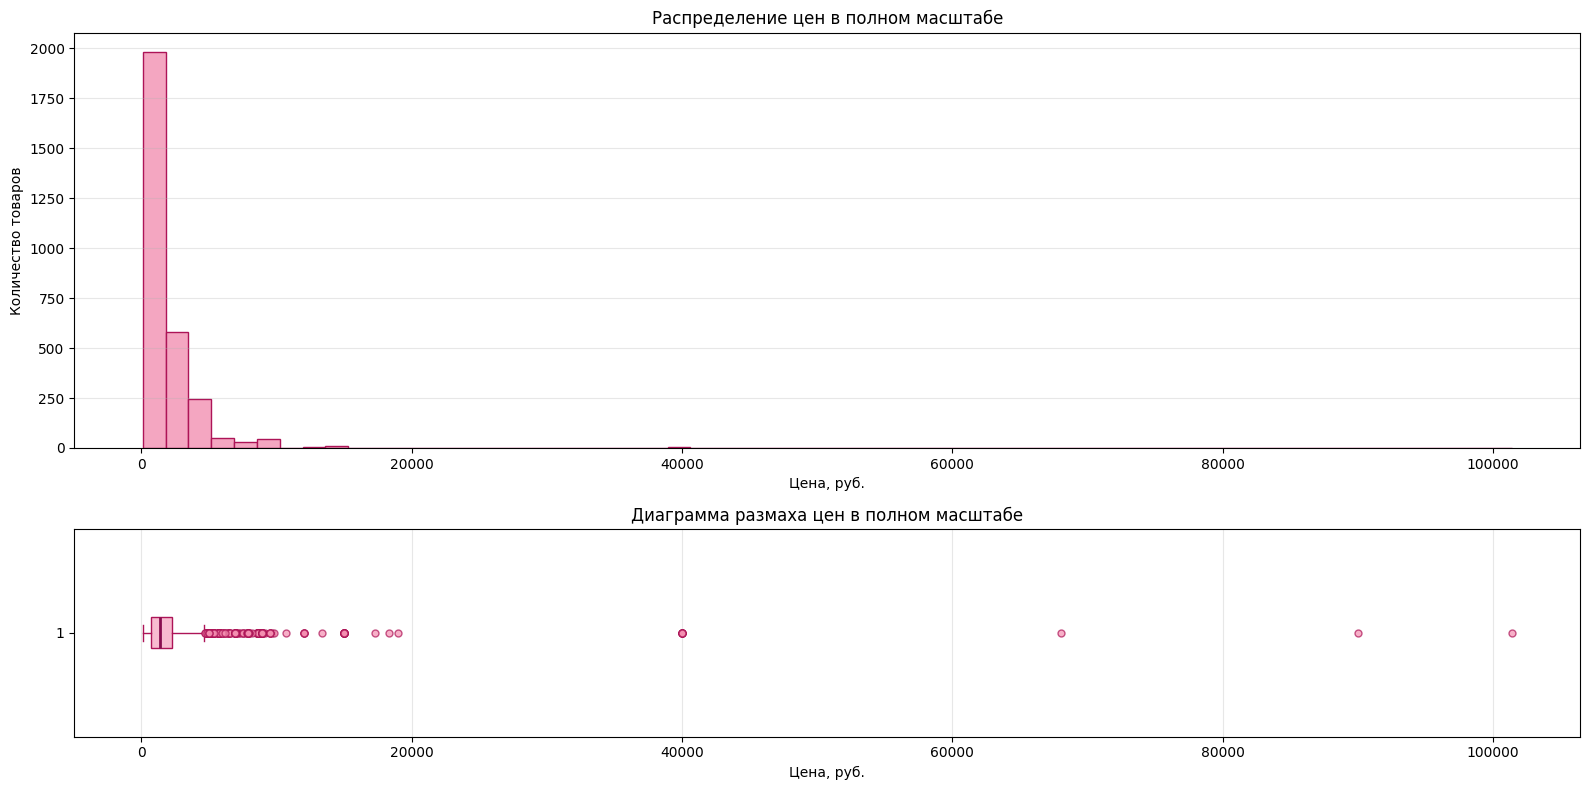

In [ ]:
price_data = df_clean['price'].dropna()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    gridspec_kw={'height_ratios': [2, 1]}
)

# Гистограмма в полном масштабе
axes[0].hist(
    price_data,
    bins=60,
    color='#F4A6C1',
    edgecolor='#AD1457'
)

axes[0].set_title('Распределение цен в полном масштабе')
axes[0].set_xlabel('Цена, руб.')
axes[0].set_ylabel('Количество товаров')
axes[0].grid(axis='y', alpha=0.3)

# Диаграмма размаха в полном масштабе
axes[1].boxplot(
    price_data,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#F8BBD0', color='#AD1457'),
    medianprops=dict(color='#880E4F', linewidth=2),
    whiskerprops=dict(color='#AD1457'),
    capprops=dict(color='#AD1457'),
    flierprops=dict(
        marker='o',
        markerfacecolor='#F48FB1',
        markeredgecolor='#AD1457',
        markersize=5,
        alpha=0.7
    )
)

axes[1].set_title('Диаграмма размаха цен в полном масштабе')
axes[1].set_xlabel('Цена, руб.')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод по выбросам.**

Анализ методом межквартильного размаха (IQR) выявил 177 ценовых выбросов. Критерий Граббса показал, что максимальное значение цены является выбросом, тогда как минимальное значение находится в пределах нормы.

Есть правостороннюя асимметрия (основные данные находятся в левой половине графика), основная часть товаров сосредоточена в диапазоне до нескольких тысяч рублей, однако в ассортименте присутствует небольшое количество значительно более дорогих товаров.

В рамках данного исследования выбросы не удаляются, поскольку они отражают реальные особенности ассортимента бренда. Высокие цены могут быть связаны с коллекционными изданиями, подарочными наборами и другими специализированными товарами, представляющими интерес для дальнейшего анализа.

### 1.3. Восстановление категорий и создание признаков

Дальше выполняется предварительная работа с категориями. Часть категорий восстанавливается по `subject_id`, часть — по названию товара. Затем детальные категории объединяются в более крупные смысловые группы, чтобы анализ был читаемым.


In [ ]:
df_clean = df.copy()

# Числовые признаки
numeric_cols = ['price', 'discount_price', 'rating', 'reviews_count', 'seller_rating', 'total_quantity',
                'brand_id', 'seller_id', 'subject_id', 'subject_parent_id', 'source_page']

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Текстовые признаки
text_cols = ['product_name', 'brand', 'seller', 'category_name', 'marketplace', 'link']
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('string').str.strip()

#### 1.3.1. Восстановление детальных категорий

В исходных данных часть `category_name` пропущена или приходит из разных источников в разном виде. Сначала восстанавливаем пропуски по `subject_id`: для каждого `subject_id` берём самую частую категорию среди товаров, где категория известна.

После этого дополнительно исправляем очевидные случаи по названию товара, продавцу и источнику. Это особенно важно для дополнительных источников: например, ювелирные товары SASONKO приходят как `ЗАПОНКИ`, `ПОДВЕСКИ`, `МОНО-СЕРЬГА`, `ТОНКИЙ БРАСЛЕТ`, а обувь из «Два мяча» — как `Кеды`. Эти категории нужно нормализовать до анализа, иначе дорогие товары уходят в группу «другое» и искажают индекс премиальности.



In [ ]:
# 1. Строим словарь subject_id -> самая частая category_name
cat_map = (
    df_clean.dropna(subset=['category_name'])
    .groupby('subject_id')['category_name']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
)

# 2. Восстанавливаем пропуски category_name по subject_id
if 'category_filled' not in df_clean.columns:
    df_clean['category_filled'] = df_clean['category_name'].fillna(df_clean['subject_id'].map(cat_map))
else:
    # Если в файле уже была category_filled, всё равно пересобираем её из исходной category_name
    df_clean['category_filled'] = df_clean['category_name'].fillna(df_clean['subject_id'].map(cat_map))

df_clean['category_filled'] = df_clean['category_filled'].fillna('не определено')

print('Пропусков category_name до восстановления:', df['category_name'].isna().sum() if 'category_name' in df.columns else 'нет столбца')
print('Неопределённых категорий после восстановления по subject_id:', (df_clean['category_filled'] == 'не определено').sum())

display(df_clean[['product_name', 'subject_id', 'category_name', 'category_filled']].sample(10, random_state=42))

Пропусков category_name до восстановления: 1825
Неопределённых категорий после восстановления по subject_id: 238


,product_name,subject_id,category_name,category_filled
1750,"Воздушный пластилин,12 цветов, 30 г, в ведерке",713.00,<NA>,пластилин
1583,Набор для опытов «Смешарики» 7 увлекательных э...,"2,619.00",<NA>,наборы для опытов
2741,Вафельная картинка на торт Смешарики с днем ро...,"3,421.00",<NA>,декор для выпечки
736,"Рюкзак, 23х21х10 см",138.00,рюкзаки,рюкзаки
2688,Сахарная картинка смешарики съедобная для торт...,"3,421.00",<NA>,декор для выпечки
781,"Раскраски для детей, 16 стр, формат А5",338.00,<NA>,раскраски
1937,Пластиковая точилка,574.00,<NA>,точилки
807,Цветной двусторонний картон с блёстками А4 10 ...,"1,395.00",<NA>,картон
1736,"Гибкий веер-касса с цифрами 1-20 для счета, 2 шт","2,338.00",<NA>,не определено
332,"Цветной картон с блестками A4, двусторонний, 1...","1,395.00",<NA>,картон


In [ ]:
def category_by_name(row):
    """
    Восстанавливает и нормализует детальную категорию товара.

    Важно: здесь мы исправляем не только пустые category_name, но и категории,
    которые есть в данных, но пришли слишком общими/нестандартизированными
    из дополнительных источников: например ЗАПОНКИ, МОНО-СЕРЬГА, ПОДВЕСКИ,
    ТОНКИЙ БРАСЛЕТ, Кеды и т.д.
    """
    cat = str(row.get('category_filled', '')).lower().strip()
    name = str(row.get('product_name', '')).lower().strip()
    seller = str(row.get('seller', '')).lower().strip()
    marketplace = str(row.get('marketplace', '')).lower().strip()

    # Смотрим сразу на название, исходную категорию, продавца и источник.
    # Это помогает корректно поймать товары из SASONKO, где category_name часто нестандартная.
    text = ' '.join([name, cat, seller, marketplace])

    # 1. Отдельно нормализуем ювелирку и украшения.
    # Этот блок стоит в самом начале, потому что такие товары дорогие и важны для анализа премиальности.
    if any(w in text for w in [
        'запонк',
        'моно-серьг', 'моно серьг',
        'серьг', 'серёжк', 'сережк',
        'гвоздик',
        'подвеск', 'кулон',
        'браслет',
        'кольц',
        'серебро', '925',
        'ювелир', 'sasonko'
    ]):
        if 'запонк' in text:
            return 'запонки'
        if 'моно-серьг' in text or 'моно серьг' in text:
            return 'моно-серьги'
        if 'гвоздик' in text or 'серьг' in text or 'серёжк' in text or 'сережк' in text:
            return 'серьги'
        if 'подвеск' in text or 'кулон' in text:
            return 'подвески'
        if 'браслет' in text:
            return 'браслеты'
        if 'кольц' in text:
            return 'кольца'
        return 'украшения и ювелирные изделия'

    # 2. Обувь из «Два мяча» тоже нормализуем до детальной категории,
    # чтобы она не уходила в «другое».
    if any(w in text for w in ['кеды', 'кед ', 'обувь']):
        return 'обувь'

    # 3. Исправляем очевидные ошибки WB даже если category_name не пустая.
    if (
        any(w in name for w in ['водн', 'пистолет', 'пушка', 'бластер'])
        and 'пневматическое оружие' in cat
    ):
        return 'игрушечное оружие'

    # 4. Мыльные пузыри иногда приходят без категории, но по смыслу это детский игровой товар.
    if any(w in text for w in ['мыльные пузыри', 'мыльн', 'пузыри']):
        return 'мыльные пузыри'

    # 5. Доразмечаем то, что осталось неопределённым.
    if cat in ['не определено', 'nan', 'none', '<na>', '']:

        # зонт
        if 'зонт' in name:
            return 'зонты'

        # мешок для обуви
        if 'мешок для сменной обуви' in name or 'мешок для обуви' in name:
            return 'мешки для обуви'

        # набор инструментов
        if 'набор инструментов' in name or 'инструмент' in name:
            return 'игровые наборы'

        # нижнее белье / одежда
        if any(w in name for w in [
            'трусы', 'боксер', 'боксеры', 'ночная сорочка',
            'сорочка', 'футболк', 'толстовк', 'свитшот',
            'лонгслив', 'пижам', 'шорт', 'джинс',
            'носки', 'шапк', 'панама', 'джемпер',
            'рубашк', 'леггинс', 'брюк', 'штаны',
            'худи', 'костюм'
        ]):
            return 'одежда'

        # стикеры / наклейки
        if any(w in name for w in ['стикер', 'стикеры', 'наклейк']):
            return 'наклейки'

        # посуда / бутылки
        if any(w in name for w in [
            'термостакан', 'бутылка', 'бутылка для воды',
            'кружк', 'ланч-бокс', 'ланчбокс', 'контейнер'
        ]):
            return 'посуда'

        # книги / печатная продукция
        if any(w in name for w in [
            'книг', 'комикс', 'журнал', 'раскраск',
            'энциклопед', 'сказк', 'альбом наклеек'
        ]):
            return 'книги'

        # игрушки и игры
        if any(w in name for w in [
            'игруш', 'пазл', 'конструкт', 'кубик',
            'настольн', 'игровой набор', 'игровые наборы',
            'фигурк', 'водн', 'пистолет', 'пушка',
            'бластер', 'антистресс', 'сквиш', 'сортер'
        ]):
            return 'игрушки'

        # канцелярия
        if any(w in name for w in [
            'тетрад', 'карандаш', 'пенал', 'папк',
            'ручк', 'блокнот', 'открытк', 'картон',
            'бумаг', 'ножницы', 'линейк'
        ]):
            return 'канцелярия'

        # творчество
        if any(w in name for w in [
            'пластилин', 'тесто для лепки', 'мел',
            'краск', 'мозаик', 'оригами',
            'набор для творчества', 'набор для поделок',
            'аппликац'
        ]):
            return 'товары для творчества'

        # еда и сладости
        if any(w in name for w in [
            'конфет', 'шоколад', 'мармелад', 'пряник',
            'сок ', 'соки', 'суп', 'макарон',
            'печень', 'свитбокс', 'яйцо', 'яйца'
        ]):
            return 'еда и сладости'

        # сумки / рюкзаки
        if any(w in name for w in ['рюкзак', 'сумк', 'портфел', 'шоппер']):
            return 'сумки и рюкзаки'

        # праздник
        if any(w in name for w in [
            'воздушные шарики', 'воздушные шары',
            'колпак', 'гирлянд', 'свеч', 'скатерт',
            'день рождения', 'топпер', 'салфетк'
        ]):
            return 'товары для праздника'

        # дом и текстиль
        if any(w in name for w in [
            'постельное белье', 'постельное бельё',
            'пододеяльник', 'плед', 'подушк',
            'полотенц', 'грелк', 'ростомер'
        ]):
            return 'товары для дома'

        # аксессуары / сувениры
        if any(w in name for w in [
            'брелок', 'значк', 'обложка на паспорт',
            'термонаклейк', 'термоаппликац', 'заплатк'
        ]):
            return 'аксессуары'

    return row['category_filled']


# Применяем нормализацию детальных категорий.
df_clean['category_filled'] = df_clean.apply(category_by_name, axis=1)

print('Топ детальных категорий после восстановления и нормализации:')
display(df_clean['category_filled'].value_counts().head(20))

print('Проверка дорогих товаров после нормализации category_filled:')
display(
    df_clean[
        df_clean['price'].notna()
    ][['product_name', 'category_name', 'category_filled', 'marketplace', 'seller', 'price']]
    .sort_values('price', ascending=False)
    .head(20)
)



Топ детальных категорий после восстановления и нормализации:


,count
category_filled,
декор для выпечки,362
альбомы для творчества,277
игрушечное оружие,192
книги,169
картон,166
рюкзаки,121
наборы для опытов,97
раскраски,91
цветная бумага,89


Проверка дорогих товаров после нормализации category_filled:


,product_name,category_name,category_filled,marketplace,seller,price
2902,"Серебряная монета 3 рубля 2023 СПМД Proof ""Рос...",<NA>,не определено,Ozon,MONETNIK,101364
2957,Запонки Cет 10,ЗАПОНКИ,запонки,Ювелирный дом SASONKO,Ювелирный дом SASONKO,90000
2956,Запонки Cет 5,ЗАПОНКИ,запонки,Ювелирный дом SASONKO,Ювелирный дом SASONKO,68000
2006,"Водный пистолет 'Брызгалка', МИКС",игрушечное оружие,игрушечное оружие,Wildberries,Гудс & Mo,40000
1958,Водный бластер «Пулялка» Микс,игрушечное оружие,игрушечное оружие,Wildberries,Гудс & Mo,40000
2041,Водный пистолет «Брызгалка» МИКС,игрушечное оружие,игрушечное оружие,Wildberries,Гудс & Mo,40000
1883,"Гармошка губная, МИКС",<NA>,игрушечные музыкальные инструменты,Wildberries,Гудс & Mo,40000
1795,Мелки цветные школьные 6шт прямоугольные,мел,мел,Wildberries,Гудс & Mo,40000
1519,Губная гармошка МИКС для детей и взрослых,<NA>,игрушечные музыкальные инструменты,Wildberries,Гудс & Mo,40000
1579,"Водный бластер Пулялка, МИКС",игрушечное оружие,игрушечное оружие,Wildberries,Гудс & Mo,40000


In [ ]:
# Контроль качества: что осталось неопределённым
unknown_categories = df_clean[df_clean['category_filled'] == 'не определено'][
    ['product_name', 'subject_id', 'category_name', 'category_filled']
].sort_values('product_name')

display(unknown_categories.head(10))
print('Всего осталось неопределённых:', len(unknown_categories))

,product_name,subject_id,category_name,category_filled
2890,25 рублей 2023 - 2025 ММД Российская советская...,NaN,<NA>,не определено
2891,25 рублей 2023 ММД Российская советская мульти...,NaN,<NA>,не определено
2901,25 рублей 2023 ММД Российская советская мульти...,NaN,<NA>,не определено
2896,500 увлекательных заданий со Смешариками для д...,NaN,<NA>,не определено
2899,SCANDIC Смешарики яблочные драже 18 штук,NaN,<NA>,не определено
2883,SCANDIC Смешарики яблочный 4 штуки,NaN,<NA>,не определено
916,Азбука здоровья (DVD),"1,135.00",<NA>,не определено
451,Веер-касса гибкие цифры прямого и обратного сч...,"2,338.00",<NA>,не определено
1366,"Гибкие цифры от 1 до 20 для обучения счёту, 2 шт","2,338.00",<NA>,не определено
1736,"Гибкий веер-касса с цифрами 1-20 для счета, 2 шт","2,338.00",<NA>,не определено


Всего осталось неопределённых: 39


In [ ]:
# Контроль качества: подозрительные товары с оружием
weapons_check = df_clean[
    df_clean['category_filled'].astype(str).str.lower().str.contains('оруж', na=False)
][['product_name', 'subject_id', 'category_name', 'category_filled']]

display(weapons_check.head(10))
print('Всего товаров с "оруж" в category_filled:', len(weapons_check))

,product_name,subject_id,category_name,category_filled
32,Водная пушка,124.00,пневматическое оружие,игрушечное оружие
33,Игровой набор детский водный ранец с пистолето...,124.00,<NA>,игрушечное оружие
51,Водный пистолет Микс Детское оружие,124.00,игрушечное оружие,игрушечное оружие
55,Водный пистолет Микс Детское оружие,124.00,игрушечное оружие,игрушечное оружие
64,"Водная пушка, пистолет 30 см МИКС",124.00,<NA>,игрушечное оружие
78,Водный пистолет с ранец-баллоном и героями,124.00,<NA>,игрушечное оружие
81,"Водный пистолет ""Брызгалка"" цвет красный",124.00,игрушечное оружие,игрушечное оружие
90,Водный пистолет игрушечное оружие,124.00,игрушечное оружие,игрушечное оружие
94,Водная пушка игрушечный пистолет 30 см МИКС,124.00,игрушечное оружие,игрушечное оружие
120,"Водный пистолет «Крош и Ёжик», МИКС",124.00,<NA>,игрушечное оружие


Всего товаров с "оруж" в category_filled: 192


#### 1.3.2. Укрупнение категорий

Категории из источников слишком детальные, поэтому для исследования создаём `macro_category` — более крупную смысловую группу товара.

Важно: макрокатегории строятся не только по `category_filled`, но и по `product_name`. Это нужно, потому что часть категорий была пропущена или размечена неточно.


In [ ]:
def macro_category(row):
    cat = str(row.get('category_filled', '')).lower().strip()
    name = str(row.get('product_name', '')).lower().strip()
    seller = str(row.get('seller', '')).lower().strip()
    marketplace = str(row.get('marketplace', '')).lower().strip()

    # Объединяем категорию, название товара, продавца и источник.
    # Так макрокатегория корректно ловит товары из дополнительных источников,
    # где category_name может быть нестандартной.
    s = ' '.join([cat, name, seller, marketplace])

    jewelry = [
        'запонк', 'моно-серьг', 'моно серьг', 'серьг', 'серёжк', 'сережк',
        'гвоздик', 'подвеск', 'кулон', 'браслет', 'кольц', 'ювелир',
        'серебро', '925', 'sasonko'
    ]

    packaging = [
        'подарочн', 'упаков', 'подарочный пакет', 'пакет подарочный',
        'коробка подарочная', 'подарочная коробка', 'бокс подарочный',
        'бумага подарочная'
    ]

    books_media = [
        'книг', 'журнал', 'раскраск', 'комикс', 'dvd',
        'мультивселенная', 'сказк', 'энциклопед'
    ]

    stationery = [
        'тетрад', 'карандаш', 'точил', 'папк', 'пенал', 'картон', 'бумаг',
        'открытк', 'счетный материал', 'счётный материал', 'веер-касса',
        'касс-веер', 'гибкие цифры', 'ножницы', 'канцеляр', 'блокнот',
        'ручк', 'линейк', 'ластик'
    ]

    creativity = [
        'альбом', 'пластилин', 'мел', 'краск', 'тесто для лепки',
        'наборы для лепки', 'набор для лепки', 'наборы для поделок',
        'набор для поделок', 'мозаик', 'оригами', 'шиммерная бумага',
        'цветовые веера', 'для творчества', 'поделок', 'аппликац'
    ]

    toys = [
        'игруш', 'конструкт', 'кубик', 'настольн', 'пазл', 'автотрек',
        'опыт', 'жвачка', 'игровые наборы', 'игровой набор',
        'сюжетные игровые наборы', 'спортивные игровые наборы', 'юла',
        'фигурк', 'лейки детские', 'для ванной', 'водн', 'пистолет',
        'пушка', 'бластер', 'антистресс', 'сквиш', 'сортер', 'бусинки',
        'музыкальные инструменты', 'развивающие', 'мыльные пузыри', 'мыльн', 'пузыри'
    ]

    food = [
        'конфет', 'пряник', 'декор для выпечки', 'слад', 'кондитер',
        'шоколад', 'шоколадн', 'яйца', 'яйцо', 'соки', 'сок ', 'суп',
        'макарон', 'мармелад', 'свитбокс', 'продукт', 'печень', 'леденц',
        'карамел', 'торт', 'съедобн'
    ]

    # Важно: не пишем просто "футбол", иначе пазлы про футбол попадут в одежду.
    clothes = [
        'одежд', 'обувь', 'кеды', 'кед ', 'футболк', 'толстовк', 'свитшот',
        'лонгслив', 'пижам', 'шорт', 'джинс', 'топ для девочки', 'топ детский',
        'топ ', 'носки', 'шапк', 'панама', 'джемпер', 'рубашк', 'трусы',
        'леггинс', 'брюк', 'штаны', 'зипк', 'оверсайз', 'худи', 'костюм',
        'комплект одежды'
    ]

    bags = ['рюкзак', 'сумк', 'портфел', 'мешок для обуви', 'мешки для обуви', 'шоппер']

    accessories = [
        'брелок', 'значк', 'обложка на паспорт', 'наклейк', 'заплатк',
        'декор для одежды', 'термонаклейк', 'термоаппликац', 'аксессуар'
    ]

    # Важно: не используем просто "шарик", потому что это слово ловится внутри "Смешарики".
    party = [
        'воздушные шарики', 'воздушные шары', 'шары воздушные', 'воздушн',
        'колпак', 'день рождения', 'наборы для праздника', 'набор для праздника',
        'аксессуары для праздника', 'скатерт', 'свеч', 'гирлянд',
        'декор для праздника', 'одноразовая посуда', 'тарелк', 'стаканчики',
        'салфетк', 'топпер', 'праздничн'
    ]

    dishes = [
        'термостакан', 'бутылка для воды', 'бутылк', 'ланч-бокс', 'ланчбокс',
        'контейнер', 'кружк', 'посуда', 'поильник'
    ]

    home = [
        'пододеяльник', 'постельное белье', 'постельное бельё', 'белье', 'бельё',
        'грелк', 'кулер', 'ростомер', 'плед', 'подушк', 'полотенц', 'текстиль'
    ]

    sport_seasonal = ['ватрушк', 'санки', 'ледянк', 'тюбинг']

    # Порядок важен: сначала более точные и проблемные категории.
    # Ювелирку ставим до аксессуаров, потому что аналитически это отдельный дорогой сегмент.
    if any(w in s for w in jewelry):
        return 'украшения и ювелирка'
    if any(w in s for w in packaging):
        return 'подарочная упаковка'
    if any(w in s for w in books_media):
        return 'книги и медиа'
    if any(w in s for w in stationery):
        return 'канцелярия'
    if any(w in s for w in creativity):
        return 'творчество и лепка'
    if any(w in s for w in toys):
        return 'игрушки и игры'
    if any(w in s for w in food):
        return 'еда и сладости'
    if any(w in s for w in clothes):
        return 'одежда и обувь'
    if any(w in s for w in bags):
        return 'сумки и рюкзаки'
    if any(w in s for w in accessories):
        return 'аксессуары и сувениры'
    if any(w in s for w in party):
        return 'праздник и декор'
    if any(w in s for w in dishes):
        return 'посуда и товары для еды'
    if any(w in s for w in home):
        return 'товары для дома и текстиль'
    if any(w in s for w in sport_seasonal):
        return 'спорт и сезонные товары'

    if cat in ['не определено', 'nan', 'none', '<na>', '']:
        return 'не определено'

    return 'другое'


df_clean['macro_category'] = df_clean.apply(macro_category, axis=1)

display(df_clean['macro_category'].value_counts())

print('Проверка: самые дорогие товары после укрупнения категорий')
display(
    df_clean[['product_name', 'category_filled', 'macro_category', 'marketplace', 'seller', 'price']]
    .sort_values('price', ascending=False)
    .head(30)
)

print('Что осталось в категории "другое":')
display(
    df_clean[df_clean['macro_category'] == 'другое'][
        ['product_name', 'category_filled', 'macro_category', 'marketplace', 'seller', 'price']
    ]
    .sort_values('price', ascending=False)
    .head(30)
)



,count
macro_category,
игрушки и игры,579
канцелярия,564
творчество и лепка,515
еда и сладости,465
книги и медиа,328
сумки и рюкзаки,158
подарочная упаковка,100
украшения и ювелирка,68
праздник и декор,65


Проверка: самые дорогие товары после укрупнения категорий


,product_name,category_filled,macro_category,marketplace,seller,price
2902,"Серебряная монета 3 рубля 2023 СПМД Proof ""Рос...",не определено,не определено,Ozon,MONETNIK,101364
2957,Запонки Cет 10,запонки,украшения и ювелирка,Ювелирный дом SASONKO,Ювелирный дом SASONKO,90000
2956,Запонки Cет 5,запонки,украшения и ювелирка,Ювелирный дом SASONKO,Ювелирный дом SASONKO,68000
2006,"Водный пистолет 'Брызгалка', МИКС",игрушечное оружие,игрушки и игры,Wildberries,Гудс & Mo,40000
1958,Водный бластер «Пулялка» Микс,игрушечное оружие,игрушки и игры,Wildberries,Гудс & Mo,40000
2041,Водный пистолет «Брызгалка» МИКС,игрушечное оружие,игрушки и игры,Wildberries,Гудс & Mo,40000
1883,"Гармошка губная, МИКС",игрушечные музыкальные инструменты,игрушки и игры,Wildberries,Гудс & Mo,40000
1795,Мелки цветные школьные 6шт прямоугольные,мел,творчество и лепка,Wildberries,Гудс & Mo,40000
1519,Губная гармошка МИКС для детей и взрослых,игрушечные музыкальные инструменты,игрушки и игры,Wildberries,Гудс & Mo,40000
1579,"Водный бластер Пулялка, МИКС",игрушечное оружие,игрушки и игры,Wildberries,Гудс & Mo,40000


Что осталось в категории "другое":


,product_name,category_filled,macro_category,marketplace,seller,price
2224,Зонт-трость со Смешариками,зонты,другое,Wildberries,АО ПЛЭЙТУДЭЙ СНГ,1747
28,Благодарность -грамота,грамоты и дипломы,другое,Wildberries,MaxSeller,711
58,"Набор на выпускной ""Выпускник детского сада""",грамоты и дипломы,другое,Wildberries,ПРЯМОЙ КОНТРАКТ - Официальный магазин,517


In [ ]:
# Проверяем, что осталось в "не определено" и "другое"
for group_name in ['не определено', 'другое']:
    print('\n', '=' * 80)
    print(group_name)
    display(
        df_clean[df_clean['macro_category'] == group_name]
        [['product_name', 'subject_id', 'category_name', 'category_filled', 'macro_category']]
        .sort_values('product_name')
        .head(10)
    )
    print('Всего:', (df_clean['macro_category'] == group_name).sum())


не определено


,product_name,subject_id,category_name,category_filled,macro_category
2890,25 рублей 2023 - 2025 ММД Российская советская...,NaN,<NA>,не определено,не определено
2891,25 рублей 2023 ММД Российская советская мульти...,NaN,<NA>,не определено,не определено
2901,25 рублей 2023 ММД Российская советская мульти...,NaN,<NA>,не определено,не определено
2896,500 увлекательных заданий со Смешариками для д...,NaN,<NA>,не определено,не определено
2899,SCANDIC Смешарики яблочные драже 18 штук,NaN,<NA>,не определено,не определено
2883,SCANDIC Смешарики яблочный 4 штуки,NaN,<NA>,не определено,не определено
2853,Дневник для 1-11 классов Hatber 40л А5 твердый...,NaN,<NA>,не определено,не определено
2870,Дневник для 1-11 классов Hatber 40л А5 твердый...,NaN,<NA>,не определено,не определено
2860,"Дневник школьный для 1-4 кл. 48 листов, тверды...",NaN,<NA>,не определено,не определено
2856,"Дневник школьный для 1-4 кл. 48 листов, тверды...",NaN,<NA>,не определено,не определено


Всего: 15

другое


,product_name,subject_id,category_name,category_filled,macro_category
28,Благодарность -грамота,"3,618.00",грамоты и дипломы,грамоты и дипломы,другое
2224,Зонт-трость со Смешариками,61.00,<NA>,зонты,другое
58,"Набор на выпускной ""Выпускник детского сада""","3,618.00",<NA>,грамоты и дипломы,другое


Всего: 3


In [ ]:
# Дополнительные признаки для дальнейшего анализа

# Если цена со скидкой отсутствует, используем обычную цену как фактическую
if 'discount_price' not in df_clean.columns:
    df_clean['discount_price'] = df_clean['price']

df_clean['discount_price'] = df_clean['discount_price'].fillna(df_clean['price'])

# Скидка в рублях и процентах
df_clean['discount_abs'] = df_clean['price'] - df_clean['discount_price']
df_clean['discount_percent'] = df_clean['discount_abs'] / df_clean['price'] * 100
df_clean['discount_percent'] = df_clean['discount_percent'].replace([np.inf, -np.inf], np.nan)

# Отзывы и рейтинг
df_clean['reviews_count'] = df_clean['reviews_count'].fillna(0)
df_clean['has_reviews'] = df_clean['reviews_count'] > 0
df_clean['rating_active'] = df_clean['rating'].where(df_clean['has_reviews'])
df_clean['log_reviews'] = np.log1p(df_clean['reviews_count'])

# Условный продавец/лицензиат для группировок
df_clean['licensee_proxy'] = (
    df_clean['seller']
    .fillna(df_clean['brand'])
    .fillna(df_clean.get('marketplace', 'Не указан'))
    .astype('string')
)

# Ценовые сегменты
bins = [-np.inf, 500, 1500, 5000, np.inf]
labels = ['до 500 ₽', '500–1500 ₽', '1500–5000 ₽', 'дороже 5000 ₽']

df_clean['price_segment'] = pd.cut(
    df_clean['discount_price'],
    bins=bins,
    labels=labels
)

print('Созданы признаки: discount_abs, discount_percent, has_reviews, rating_active, log_reviews, licensee_proxy, price_segment')
display(df_clean[['product_name', 'macro_category', 'discount_price', 'price_segment', 'reviews_count', 'has_reviews']].head())


Созданы признаки: discount_abs, discount_percent, has_reviews, rating_active, log_reviews, licensee_proxy, price_segment


,product_name,macro_category,discount_price,price_segment,reviews_count,has_reviews
0,Мультивселенная. Комиксы BUBBLE,книги и медиа,990,500–1500 ₽,792.00,True
1,Школьные мелки 10 цветов 29 штук,творчество и лепка,168,до 500 ₽,241.00,True
2,Маленькая мягкая игрушка брелок Крош на рюкзак,украшения и ювелирка,385,до 500 ₽,"1,155.00",True
3,Термостакан 350 мл с клапаном,канцелярия,331,до 500 ₽,350.00,True
4,Маленькая мягкая игрушка Пин на рюкзак,игрушки и игры,398,до 500 ₽,696.00,True


**Вывод по подготовке данных.**

В ходе подготовки данных количество товаров с неопределённой категорией удалось сократить с 1825 до 238. После восстановления детальных категорий товары были объединены в 14 укрупнённых макрокатегорий, что позволило перейти от анализа отдельных товарных позиций к анализу структуры ассортимента в целом.

## 2. Ассортимент продукции

В этом блоке смотрим, какие категории товаров формируют основу ассортимента. Это помогает понять, за счёт каких товарных направлений бренд «Смешарики» присутствует в продаже: игрушек, канцелярии, одежды, книг, сладостей, аксессуаров или более нишевого мерча.


### 2.1. Структура ассортимента

Сначала рассмотрим распределение товаров по макрокатегориям. Это позволит определить основные направления развития бренда и оценить, какие группы продукции занимают наибольшую долю ассортимента.

Для анализа используются абсолютные значения, доли категорий в общем ассортименте, а также сводная таблица с количеством товаров, брендов и продавцов внутри каждой категории.

In [ ]:
# Количество товаров по макрокатегориям
category_counts = df_clean['macro_category'].value_counts()
category_share = df_clean['macro_category'].value_counts(normalize=True).mul(100).round(2)

assortment_distribution = pd.DataFrame({
    'products_count': category_counts,
    'share_percent': category_share
})

display(assortment_distribution)

,products_count,share_percent
macro_category,,
игрушки и игры,579,19.55
канцелярия,564,19.04
творчество и лепка,515,17.39
еда и сладости,465,15.70
книги и медиа,328,11.07
сумки и рюкзаки,158,5.33
подарочная упаковка,100,3.38
украшения и ювелирка,68,2.30
праздник и декор,65,2.19


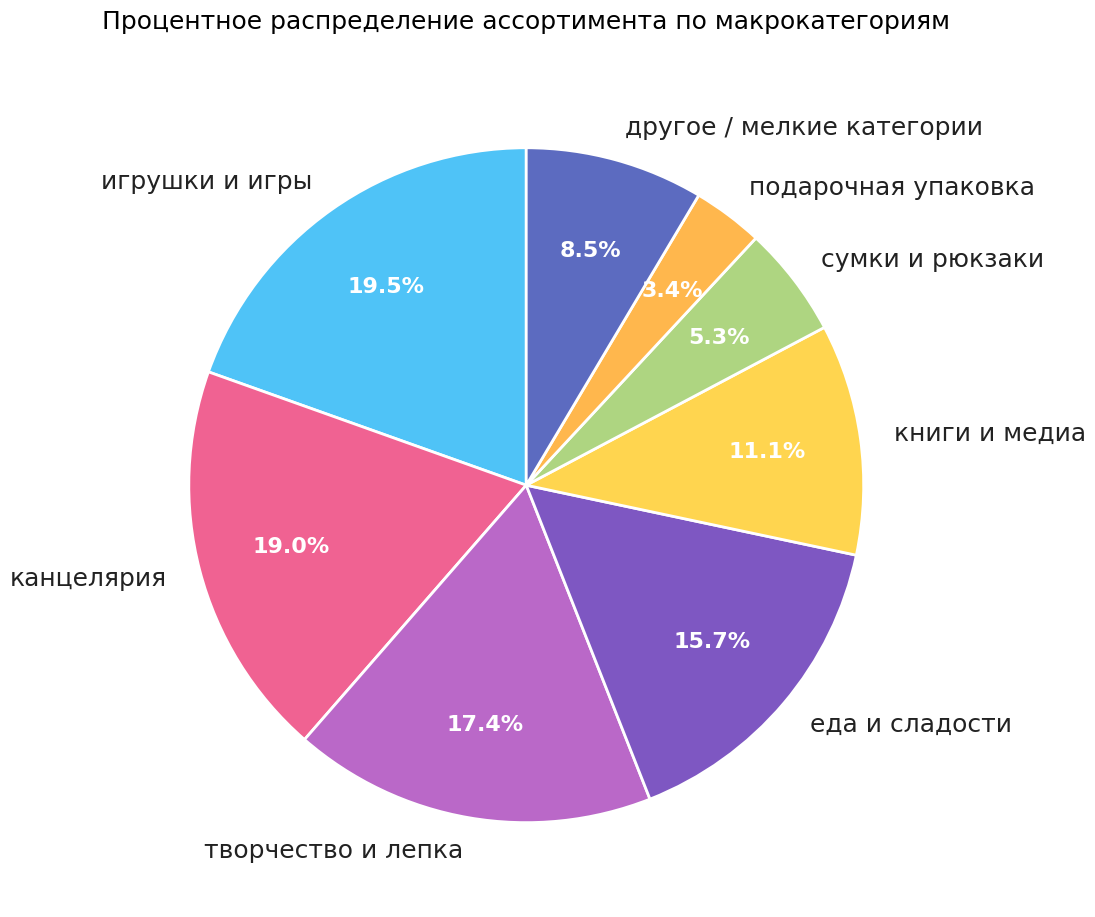

In [ ]:
# Круговая диаграмма: процентное соотношение крупных категорий

pie_data = assortment_distribution.copy()

# Чтобы диаграмма не была перегружена, мелкие категории объединяем в "другое"
threshold = 3  # проценты
small_categories = pie_data[pie_data['share_percent'] < threshold]

if len(small_categories) > 0:
    pie_main = pie_data[pie_data['share_percent'] >= threshold].copy()
    other_row = pd.DataFrame({
        'products_count': [small_categories['products_count'].sum()],
        'share_percent': [small_categories['share_percent'].sum()]
    }, index=['другое / мелкие категории'])
    pie_plot_data = pd.concat([pie_main, other_row])
else:
    pie_plot_data = pie_data.copy()

# Контрастная палитра в стиле персонажей "Смешариков"
# Цвета специально расставлены так, чтобы похожие оттенки не стояли рядом
smeshariki_palette = [
    '#4FC3F7',  # Крош — голубой
    '#F06292',  # Нюша — розовый
    '#BA68C8',  # Бараш — сиреневый
    '#7E57C2',  # Ёжик — фиолетовый
    '#FFD54F',  # Лосяш — жёлтый
    '#AED581',  # зелёный
    '#FFB74D',  # Копатыч — оранжевый
    '#5C6BC0',  # Совунья — сине-фиолетовый
    '#1E88E5',  # Кар-Карыч — синий
    '#424242',  # Пин — тёмно-серый
    '#FF8A65',  # коралловый
    '#90CAF9'   # светло-голубой
]

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(pie_plot_data))
]

plt.figure(figsize=(11, 11))

wedges, texts, autotexts = plt.pie(
    pie_plot_data['products_count'],
    labels=pie_plot_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.72,
    labeldistance=1.1,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={
        'fontsize': 13
    }
)

# Подписи категорий
for text in texts:
    text.set_fontsize(18)
    text.set_color('#222222')

# Проценты внутри секторов
for autotext in autotexts:
    autotext.set_fontsize(16)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.title(
    'Процентное распределение ассортимента по макрокатегориям',
    fontsize=18,
    pad=25
)

plt.tight_layout()
plt.show()

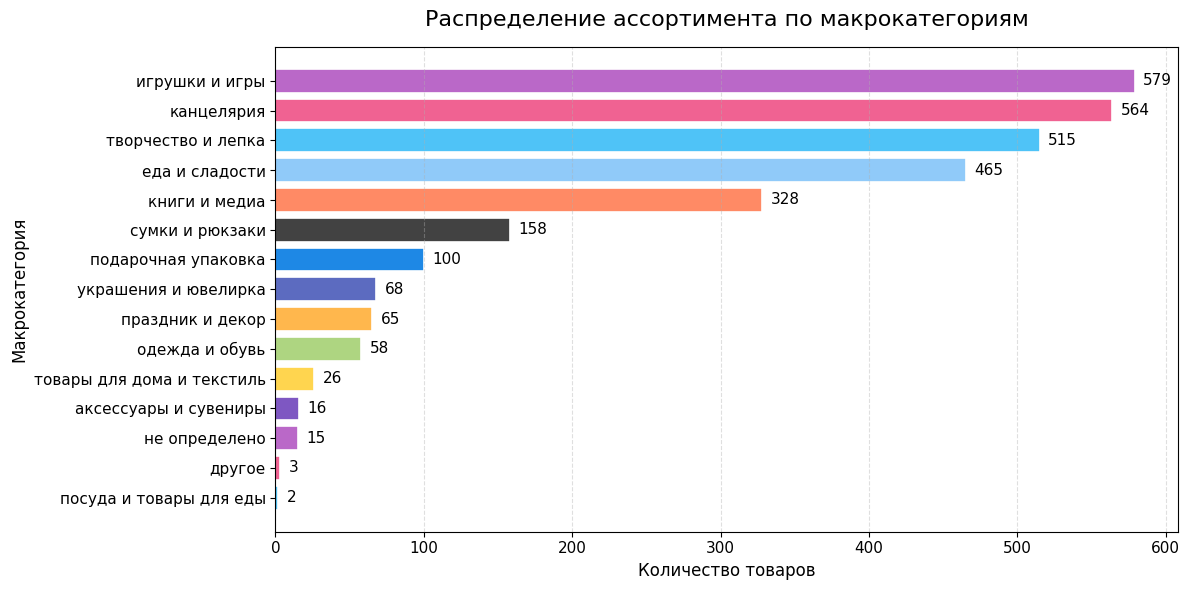

In [ ]:
category_plot = category_counts.sort_values()

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(category_plot))
]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

bars = ax.barh(
    category_plot.index,
    category_plot.values,
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

ax.set_title(
    'Распределение ассортимента по макрокатегориям',
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    'Количество товаров',
    fontsize=12
)

ax.set_ylabel(
    'Макрокатегория',
    fontsize=12
)

ax.tick_params(axis='both', labelsize=11)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max(category_plot.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

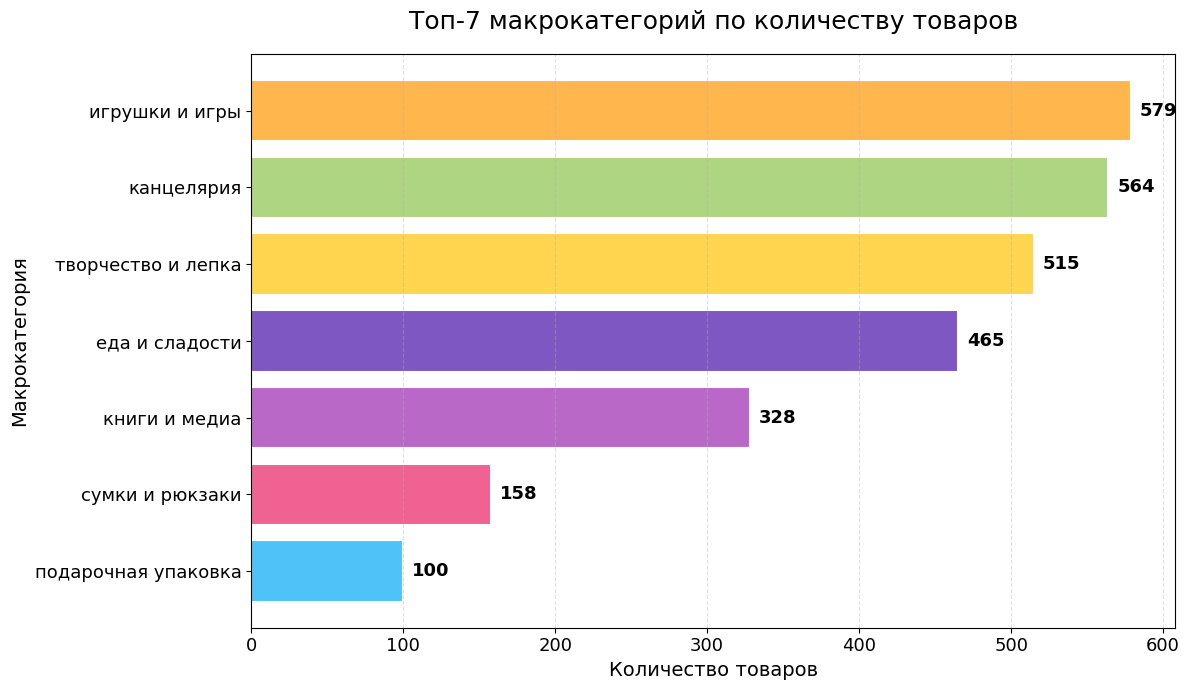

In [ ]:
# Топ-7 макрокатегорий по количеству товаров
category_plot = category_counts.sort_values(ascending=False).head(7).sort_values()

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(category_plot))
]

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars = ax.barh(
    category_plot.index,
    category_plot.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

ax.set_title(
    'Топ-7 макрокатегорий по количеству товаров',
    fontsize=18,
    pad=18
)

ax.set_xlabel(
    'Количество товаров',
    fontsize=14
)

ax.set_ylabel(
    'Макрокатегория',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=13)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

# Подписи значений справа от столбцов
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max(category_plot.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va='center',
        fontsize=13,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Ассортиментная таблица: сколько товаров, брендов и продавцов в каждой макрокатегории
assortment_table = (
    df_clean.groupby('macro_category')
    .agg(
        products_count=('product_id', 'count'),
        unique_brands=('brand', 'nunique'),
        unique_sellers=('seller', 'nunique'),
        median_price=('discount_price', 'median'),
        total_reviews=('reviews_count', 'sum')
    )
    .sort_values('products_count', ascending=False)
)

assortment_table['share_percent'] = (assortment_table['products_count'] / len(df_clean) * 100).round(2)

display(assortment_table)

,products_count,unique_brands,unique_sellers,median_price,total_reviews,share_percent
macro_category,,,,,,
игрушки и игры,579,13,166,875.00,"36,770.00",19.55
канцелярия,564,3,145,495.50,"16,766.00",19.04
творчество и лепка,515,2,81,401.00,"3,083.00",17.39
еда и сладости,465,6,12,321.00,"21,012.00",15.70
книги и медиа,328,7,118,551.50,"67,025.00",11.07
сумки и рюкзаки,158,4,98,"1,003.50","1,988.00",5.33
подарочная упаковка,100,2,48,495.50,"3,046.00",3.38
украшения и ювелирка,68,2,4,"6,950.00","68,755.00",2.30
праздник и декор,65,4,5,292.00,"32,461.00",2.19


In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

# Берём уже готовую ассортиментную таблицу
pretty_table = assortment_table.copy().reset_index()

# Переименовываем столбцы на русский
pretty_table = pretty_table.rename(columns={
    'macro_category': 'Макрокатегория',
    'products_count': 'Количество товаров',
    'unique_brands': 'Число брендов',
    'unique_sellers': 'Число продавцов',
    'median_price': 'Медианная цена, ₽',
    'total_reviews': 'Всего отзывов',
    'share_percent': 'Доля в ассортименте, %'
})

# Сортируем по доле в ассортименте
pretty_table = pretty_table.sort_values(
    by='Доля в ассортименте, %',
    ascending=False
).reset_index(drop=True)

# Нумерация строк
pretty_table.index = pretty_table.index + 1

# Функции форматирования
def fmt_int(x):
    if pd.isna(x):
        return ''
    return f'{x:,.0f}'.replace(',', ' ')

def fmt_price(x):
    if pd.isna(x):
        return ''
    return f'{x:,.0f}'.replace(',', ' ')

def fmt_percent(x):
    if pd.isna(x):
        return ''
    return f'{x:.2f}'.replace('.', ',')

# Красивая styled-таблица
styled_table = (
    pretty_table.style
    .format({
        'Количество товаров': fmt_int,
        'Число брендов': fmt_int,
        'Число продавцов': fmt_int,
        'Медианная цена, ₽': fmt_price,
        'Всего отзывов': fmt_int,
        'Доля в ассортименте, %': fmt_percent
    })
    .background_gradient(subset=['Количество товаров'], cmap='Blues')
    .background_gradient(subset=['Медианная цена, ₽'], cmap='Oranges')
    .background_gradient(subset=['Всего отзывов'], cmap='Greens')
    .background_gradient(subset=['Доля в ассортименте, %'], cmap='Purples')
    .set_caption('Сводная характеристика макрокатегорий товаров «Смешарики»')
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#FCE4EC'),
                ('color', '#222222'),
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('border', '1px solid #dddddd'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('padding', '8px'),
                ('font-size', '11px')
            ]
        }
    ])
    .set_properties(subset=['Макрокатегория'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
    .set_properties(subset=[
        'Количество товаров',
        'Число брендов',
        'Число продавцов',
        'Медианная цена, ₽',
        'Всего отзывов',
        'Доля в ассортименте, %'
    ], **{
        'text-align': 'center'
    })
)

display(styled_table)

,Макрокатегория,Количество товаров,Число брендов,Число продавцов,"Медианная цена, ₽",Всего отзывов,"Доля в ассортименте, %"
1,игрушки и игры,579,13,166,875,36 770,"19,55"
2,канцелярия,564,3,145,496,16 766,"19,04"
3,творчество и лепка,515,2,81,401,3 083,"17,39"
4,еда и сладости,465,6,12,321,21 012,"15,70"
5,книги и медиа,328,7,118,552,67 025,"11,07"
6,сумки и рюкзаки,158,4,98,1 004,1 988,"5,33"
7,подарочная упаковка,100,2,48,496,3 046,"3,38"
8,украшения и ювелирка,68,2,4,6 950,68 755,"2,30"
9,праздник и декор,65,4,5,292,32 461,"2,19"
10,одежда и обувь,58,4,7,1 204,2 483,"1,96"


**Вывод по ассортименту продукции.**

Анализ ассортимента показал, что основную долю товаров составляют категории «Игрушки и игры», «Канцелярия» и «Творчество и лепка», на которые приходится более половины всех товаров в выборке. Также значительную часть ассортимента формируют категории «Еда и сладости» и «Книги и медиа».

В исследуемом датасете представлены как официальные товары бренда «Смешарики», так и продукция лицензионных партнёров, среди которых наиболее заметны Hatber, SELA, Эксмо, Brick Labs, Мульти-пульти и другие производители.

Полученные результаты свидетельствуют о высокой диверсификации ассортимента. Бренд представлен не только в сегменте игрушек, но и в книгах, канцелярии, одежде, сладостях, товарах для творчества и других товарных категориях, что подтверждает его развитие как полноценного потребительского бренда.

In [ ]:
!pip install dataframe_image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 MB 20.6 MB/s eta 0:00:00


In [ ]:
# Сохраняем как HTML, а потом открываем в браузере или копируем
styled_table.to_html('smeshariki.html')
print("Таблица сохранена как HTML. Скачайте файл 'smeshariki.html', откройте в браузере и сделайте скриншот.")

Таблица сохранена как HTML. Скачайте файл 'smeshariki.html', откройте в браузере и сделайте скриншот.


### 2.2. Бренды и лицензионные партнёры

Помимо официальной продукции бренда «Смешарики», в датасете присутствуют товары различных лицензионных партнёров. Рассмотрим, какие бренды представлены наиболее широко и какой вклад в ассортимент вносят сторонние производители.

,products_count
brand,
Стиль Жизни,5
SCANDIC,6
Играмир,7
Не указан,7
Kinder,8
Befree,9
INFANT,9
STEP puzzle company,11
Издательство АСТ,14


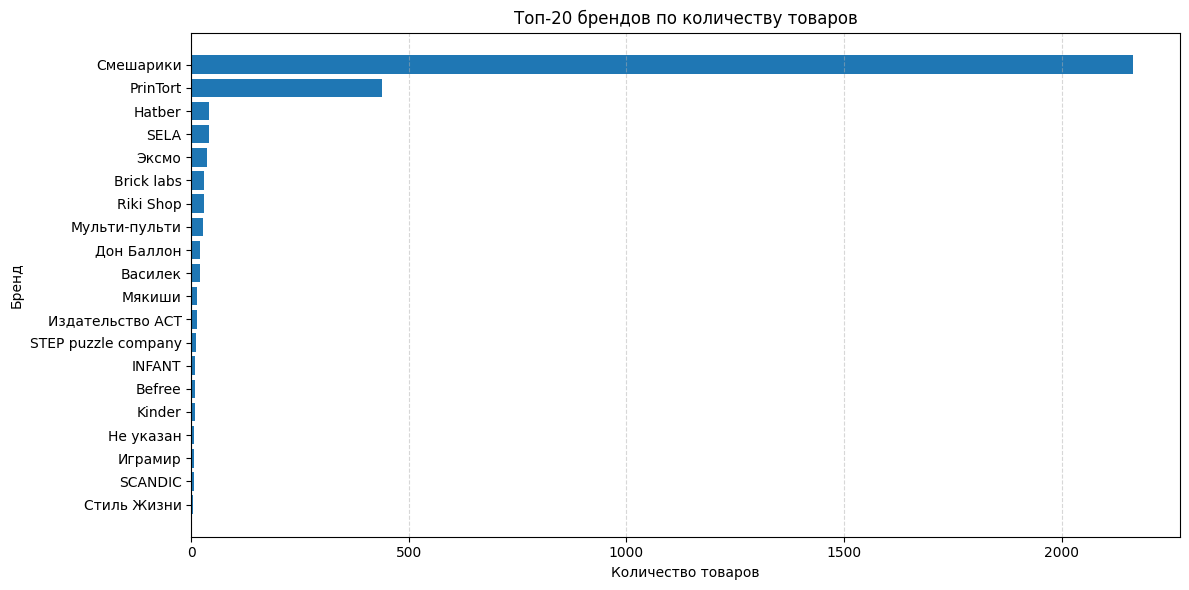

In [ ]:
# Топ брендов по количеству товаров

top_brands = (
    df_clean['brand']
    .fillna('Не указан')
    .value_counts()
    .head(20)
    .sort_values()
)

display(
    top_brands.to_frame('products_count')
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.barh(
    top_brands.index,
    top_brands.values
)

ax.set_title(
    'Топ-20 брендов по количеству товаров'
)

ax.set_xlabel(
    'Количество товаров'
)

ax.set_ylabel(
    'Бренд'
)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [ ]:
# Топ брендов: с брендом "Смешарики" и без него

df_clean['brand'] = df_clean['brand'].fillna('не указан').astype(str)

def make_brand_table(data, top_n=10):
    brand_table = (
        data.groupby('brand')
        .agg(
            products_count=('brand', 'size'),
            unique_categories=('macro_category', 'nunique'),
            median_price=('price', 'median'),
            total_reviews=('reviews_count', 'sum')
        )
        .sort_values('products_count', ascending=False)
        .head(top_n)
    )

    brand_table['share_percent'] = (
        brand_table['products_count']
        / brand_table['products_count'].sum()
        * 100
    ).round(2)

    return brand_table


# Таблица с брендом "Смешарики"
brand_table_all = make_brand_table(df_clean, top_n=10)

# Таблица без бренда "Смешарики"
df_without_smeshariki_brand = df_clean[
    ~df_clean['brand'].str.lower().str.contains('смешарики', na=False)
].copy()

brand_table_without_smeshariki = make_brand_table(
    df_without_smeshariki_brand,
    top_n=10
)

display(brand_table_all)
display(brand_table_without_smeshariki)

,products_count,unique_categories,median_price,total_reviews,share_percent
brand,,,,,
Смешарики,2164,14,"1,488.00","27,363.00",76.09
PrinTort,438,1,542.00,127.00,15.40
Hatber,41,6,548.00,"21,759.00",1.44
SELA,40,1,"3,549.00","2,028.00",1.41
Эксмо,35,5,"1,480.00","27,521.00",1.23
Brick labs,29,1,"2,068.00","3,855.00",1.02
Riki Shop,29,2,"1,000.00","1,048.00",1.02
Мульти-пульти,28,1,"3,060.50",880.00,0.98
Дон Баллон,21,1,"1,649.00","23,956.00",0.74


,products_count,unique_categories,median_price,total_reviews,share_percent
brand,,,,,
PrinTort,438,1,542.00,127.00,63.11
Hatber,41,6,548.00,"21,759.00",5.91
SELA,40,1,"3,549.00","2,028.00",5.76
Эксмо,35,5,"1,480.00","27,521.00",5.04
Brick labs,29,1,"2,068.00","3,855.00",4.18
Riki Shop,29,2,"1,000.00","1,048.00",4.18
Мульти-пульти,28,1,"3,060.50",880.00,4.03
Дон Баллон,21,1,"1,649.00","23,956.00",3.03
Василек,19,1,"6,286.00",521.00,2.74


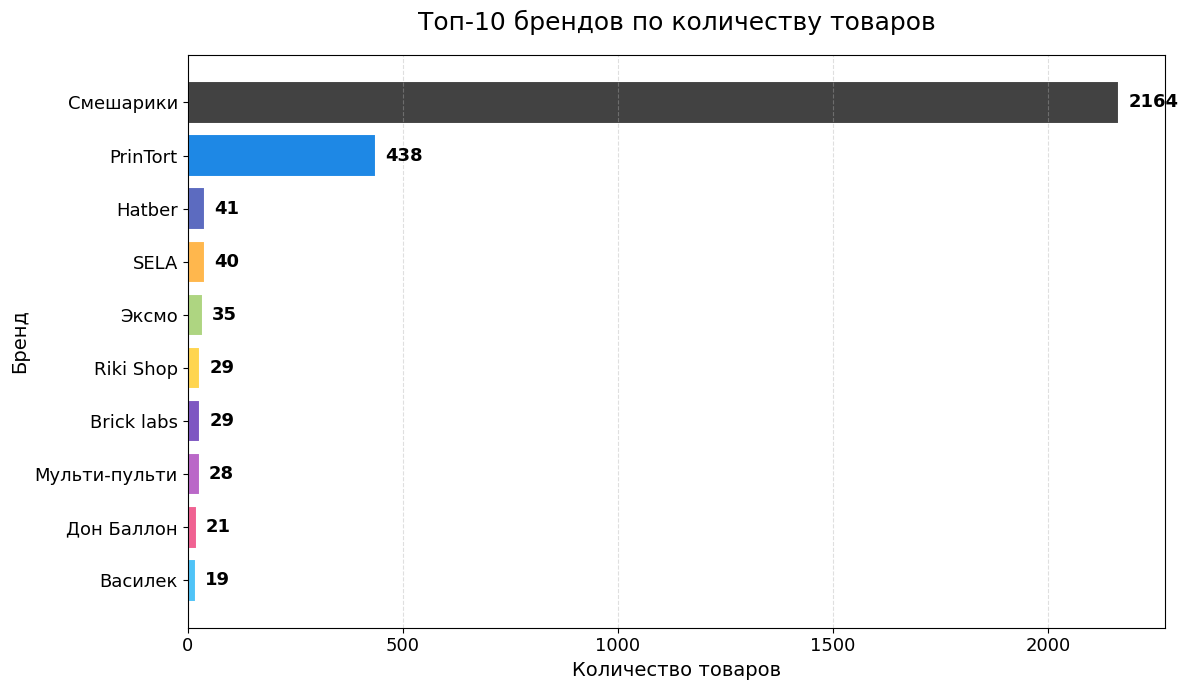

In [ ]:
# График 1: топ-10 брендов с брендом "Смешарики"

brand_plot_all = brand_table_all['products_count'].sort_values()

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(brand_plot_all))
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    brand_plot_all.index,
    brand_plot_all.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

ax.set_title(
    'Топ-10 брендов по количеству товаров',
    fontsize=18,
    pad=18
)

ax.set_xlabel(
    'Количество товаров',
    fontsize=14
)

ax.set_ylabel(
    'Бренд',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=13)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max(brand_plot_all.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va='center',
        fontsize=13,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

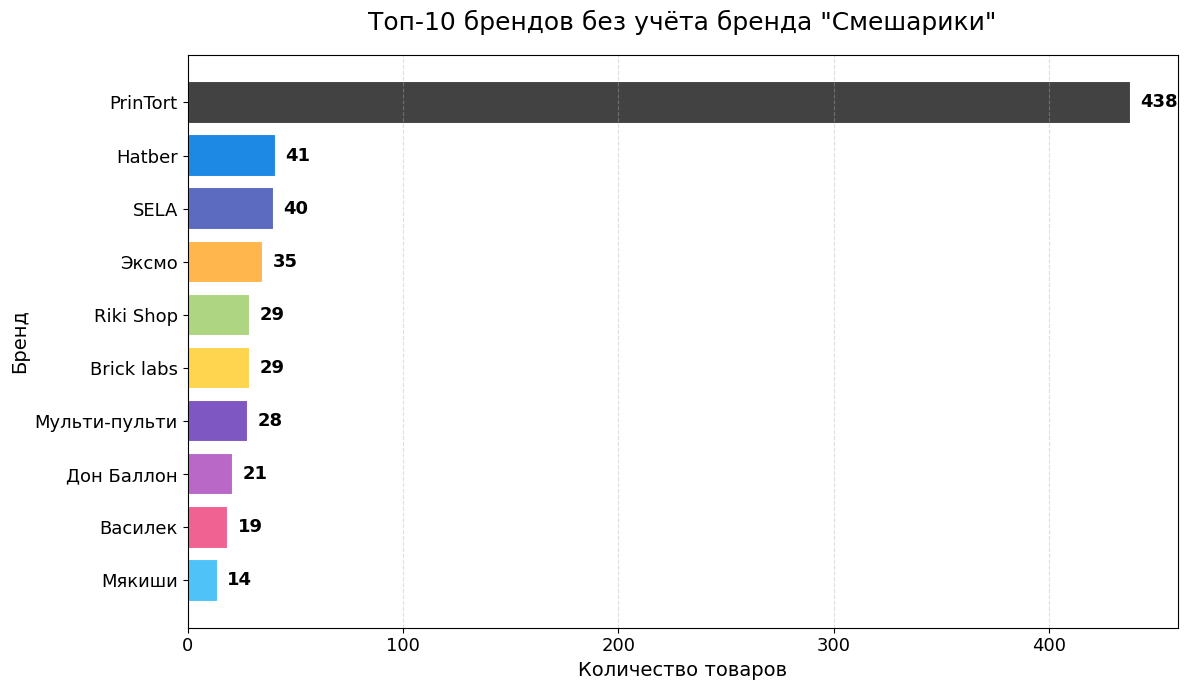

In [ ]:
# График 2: топ-10 брендов без бренда "Смешарики"

brand_plot_without = brand_table_without_smeshariki['products_count'].sort_values()

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(brand_plot_without))
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    brand_plot_without.index,
    brand_plot_without.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

ax.set_title(
    'Топ-10 брендов без учёта бренда "Смешарики"',
    fontsize=18,
    pad=18
)

ax.set_xlabel(
    'Количество товаров',
    fontsize=14
)

ax.set_ylabel(
    'Бренд',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=13)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max(brand_plot_without.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va='center',
        fontsize=13,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Распределение категорий у крупнейших продавцов

seller_category_table = pd.crosstab(
    df_clean['seller'],
    df_clean['macro_category']
)

top15_sellers = (
    df_clean['seller']
    .fillna('Не указан')
    .value_counts()
    .head(15)
    .index
)

display(
    seller_category_table.loc[top15_sellers]
)

macro_category,аксессуары и сувениры,другое,еда и сладости,игрушки и игры,канцелярия,книги и медиа,не определено,одежда и обувь,подарочная упаковка,посуда и товары для еды,праздник и декор,сумки и рюкзаки,творчество и лепка,товары для дома и текстиль,украшения и ювелирка
seller,,,,,,,,,,,,,,,
PrinTort,0,0,438,0,0,0,0,0,0,0,0,0,0,0,0
Гудс & Mo,0,0,0,18,22,7,0,0,1,0,0,0,21,0,0
Гудс & Мо,1,0,0,14,24,7,0,0,1,0,0,0,22,0,0
Официальный Магазин СИМ СИМ откройся,0,0,0,15,13,7,0,0,4,0,0,4,23,0,0
ТойсМаркет,0,0,0,15,14,5,0,2,1,0,0,1,17,0,0
Филиппи КО,0,0,0,8,17,3,0,0,5,0,0,2,16,0,0
Ювелирный дом SASONKO,0,0,0,0,0,0,0,0,0,0,0,0,0,0,48
Трифанов,0,0,0,7,11,7,0,0,3,0,0,2,17,0,0
MJShop,0,0,0,8,12,4,0,0,5,0,0,2,13,0,0


### Вывод по ассортименту

Здесь нужно описать:

- какие 3–5 категорий занимают наибольшую долю;
- насколько ассортимент разнообразен;
- какие категории выглядят массовыми, а какие более нишевыми;
- какие бренды/продавцы чаще всего встречаются.

**Черновик вывода:**  
Ассортимент показывает, что «Смешарики» представлены не только в формате игрушек. Значимую часть датасета могут занимать канцелярия, товары для творчества, книги, сладости, одежда, аксессуары и подарочные позиции. Это позволяет рассматривать бренд как широкую потребительскую франшизу, а не только как детский мультсериал.


**Вывод по ассортименту.**

Анализ ассортимента показал, что наибольшую долю товаров составляют категории **«Игрушки и игры» (19,55%)**, **«Канцелярия» (19,04%)** и **«Творчество и лепка» (17,39%)**. Вместе эти категории формируют более половины всего ассортимента. Также значительную долю занимают **еда и сладости** и **книги и медиа**, что свидетельствует о широком использовании бренда в различных товарных направлениях.

Ассортимент отличается высоким разнообразием и не ограничивается детскими игрушками. В выборке представлены книги, канцелярские товары, наборы для творчества, сладости, одежда, сумки, товары для дома, праздничная продукция и другие категории.

Наиболее массовыми категориями являются игрушки, канцелярия и товары для творчества, тогда как аксессуары и сувениры, посуда, товары для дома и отдельные специализированные категории представлены значительно меньшим количеством товаров и могут рассматриваться как второстепенные направления.

Среди продавцов наибольшее количество товаров представлено у **PrinTort** (438 товаров), а также у продавцов **Гудс & Mo** и **Гудс & Мо** (по 69 товаров) без учета магазина **Смешарики**.

In [ ]:
# Автоматическая подсказка для вывода по блоку 1

top3_categories = assortment_distribution.head(3)

top3_sellers = (
    df_clean['seller']
    .fillna('Не указан')
    .value_counts()
    .head(3)
)

print('Топ-3 макрокатегории по количеству товаров:')

for category, row in top3_categories.iterrows():
    print(
        f'- {category}: '
        f'{int(row["products_count"])} товаров '
        f'({row["share_percent"]:.2f}%)'
    )

print('\nТоп-3 продавца по количеству товаров:')

for seller, count in top3_sellers.items():
    print(
        f'- {seller}: {count} товаров'
    )

Топ-3 макрокатегории по количеству товаров:
- игрушки и игры: 579 товаров (19.55%)
- канцелярия: 564 товаров (19.04%)
- творчество и лепка: 515 товаров (17.39%)

Топ-3 продавца по количеству товаров:
- PrinTort: 438 товаров
- Гудс & Mo: 69 товаров
- Гудс & Мо: 69 товаров


## 3. Ценовая аналитика

В этом блоке анализируется, сколько стоят товары «Смешарики» и как цена различается между категориями. Так как распределение цен скошено и содержит дорогие позиции, в выводах лучше опираться не только на среднее, но и на медиану.


### 3.1. Общее распределение цен

Сначала рассмотрим основные характеристики цен и их распределение. Для этого используются описательная статистика, гистограммы распределения и диаграммы размаха. Такой подход позволяет оценить типичный уровень цен, разброс значений и наличие дорогостоящих товаров, существенно отличающихся от основной массы ассортимента.

In [ ]:
# Описательная статистика цен
price_cols = [col for col in ['price', 'discount_price', 'discount_abs', 'discount_percent'] if col in df_clean.columns]
display(df_clean[price_cols].describe())

,price,discount_price,discount_abs,discount_percent
count,"2,962.00","2,962.00","2,962.00","2,962.00"
mean,"2,078.44",959.57,"1,118.87",54.20
std,"3,813.14","2,912.01","1,866.01",19.73
min,115.00,53.00,-102.00,-8.61
25%,690.00,343.25,288.00,38.98
50%,"1,368.00",516.00,739.00,55.17
75%,"2,280.00",900.00,"1,266.00",72.01
max,"101,364.00","90,000.00","75,974.00",89.65


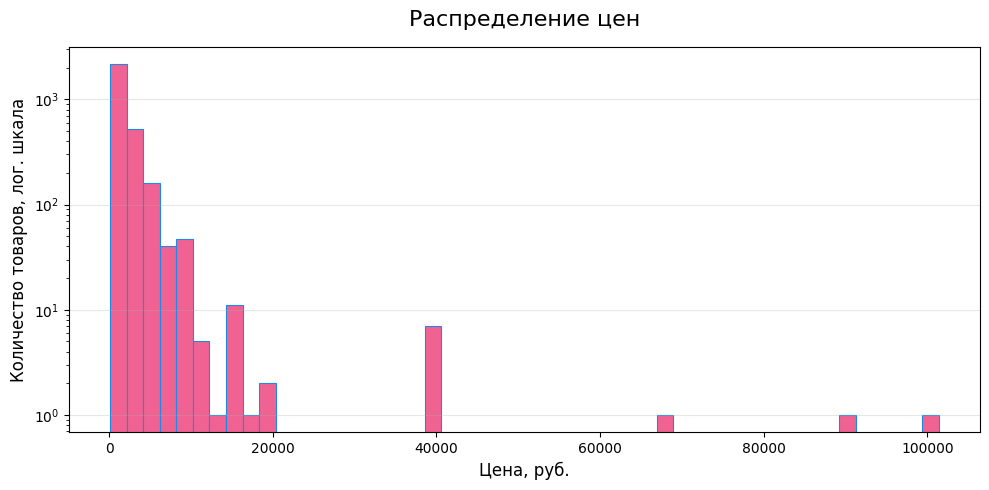

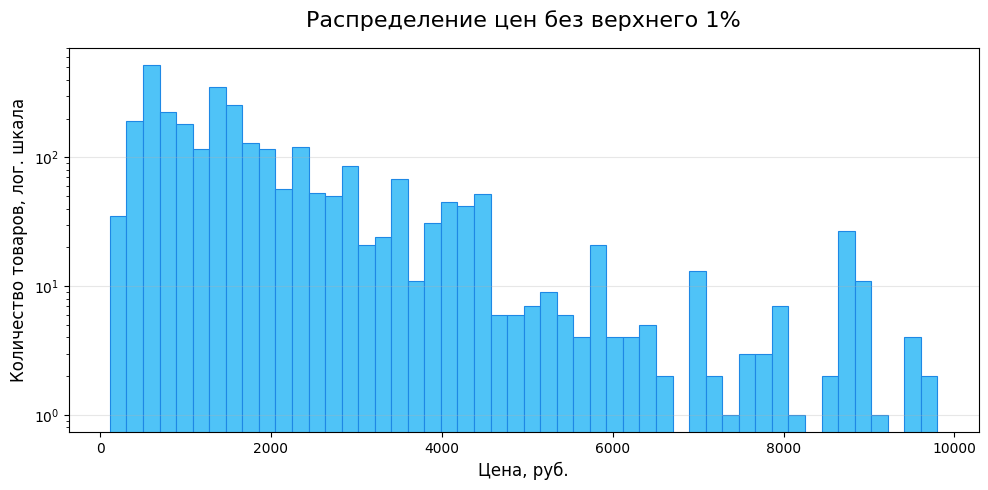

99-й процентиль цены: 10141.25 руб.


In [ ]:
# Распределение цен: полный график и график без верхнего 1% для читаемости

price_col = 'price'

main_color = smeshariki_palette[1]   # розовый
edge_color = smeshariki_palette[8]   # тёмный
second_color = smeshariki_palette[0] # голубой

plt.figure(figsize=(10, 5))

plt.hist(
    df_clean[price_col].dropna(),
    bins=50,
    color=main_color,
    edgecolor=edge_color,
    linewidth=0.8
)

plt.yscale('log')

plt.title('Распределение цен', fontsize=16, pad=15)
plt.xlabel('Цена, руб.', fontsize=12)
plt.ylabel('Количество товаров, лог. шкала', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


q99 = df_clean[price_col].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df_clean[df_clean[price_col] <= q99][price_col].dropna(),
    bins=50,
    color=second_color,
    edgecolor=edge_color,
    linewidth=0.8
)

plt.yscale('log')

plt.title('Распределение цен без верхнего 1%', fontsize=16, pad=15)
plt.xlabel('Цена, руб.', fontsize=12)
plt.ylabel('Количество товаров, лог. шкала', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'99-й процентиль цены: {q99:.2f} руб.')

**Вывод по общему распределению цен.**

Средняя цена товара составляет около 2 078 рублей, тогда как медианная цена значительно ниже и составляет 1 368 рублей. Это свидетельствует о наличии небольшого количества дорогостоящих товаров, которые заметно повышают среднее значение, как мы писали ранее.

Минимальная цена в выборке составляет 115 рублей, максимальная - 101 364 рубля. Таким образом, ассортимент охватывает как массовые товары повседневного спроса, так и отдельные дорогостоящие позиции. Распределение цен имеет выраженную правостороннюю асимметрию, поэтому для дальнейшего анализа целесообразно использовать медианную цену.

### 3.2. Цены в различных категориях товаров

После анализа общего распределения цен рассмотрим различия между макрокатегориями. Сравнение медианных и средних значений позволяет определить наиболее дорогие и наиболее доступные направления ассортимента, а также оценить разброс цен внутри отдельных категорий.

In [ ]:
# Цены по макрокатегориям
price_by_category = (
    df_clean.groupby('macro_category')
    .agg(
        products_count=('product_id', 'count'),
        mean_price=('discount_price', 'mean'),
        median_price=('discount_price', 'median'),
        min_price=('discount_price', 'min'),
        q25_price=('discount_price', lambda x: x.quantile(0.25)),
        q75_price=('discount_price', lambda x: x.quantile(0.75)),
        max_price=('discount_price', 'max')
    )
    .sort_values('median_price', ascending=False)
)

price_by_category = price_by_category.round(2)
display(price_by_category)

,products_count,mean_price,median_price,min_price,q25_price,q75_price,max_price
macro_category,,,,,,,
украшения и ювелирка,68,"8,711.53","6,950.00",223,794.25,"9,500.00",90000
товары для дома и текстиль,26,"1,279.23","1,295.00",174,"1,099.25","1,506.25",2544
одежда и обувь,58,"1,781.71","1,203.50",293,697.25,"2,164.50",7900
сумки и рюкзаки,158,"1,016.32","1,003.50",260,846.25,"1,155.25",3246
посуда и товары для еды,2,927.00,927.00,927,927.00,927.00,927
игрушки и игры,579,"1,307.22",875.00,109,509.00,"1,147.00",32000
не определено,15,"2,392.93",638.00,127,146.00,"1,232.50",25390
книги и медиа,328,614.87,551.50,78,395.00,697.25,3190
подарочная упаковка,100,596.90,495.50,210,385.00,763.00,1413


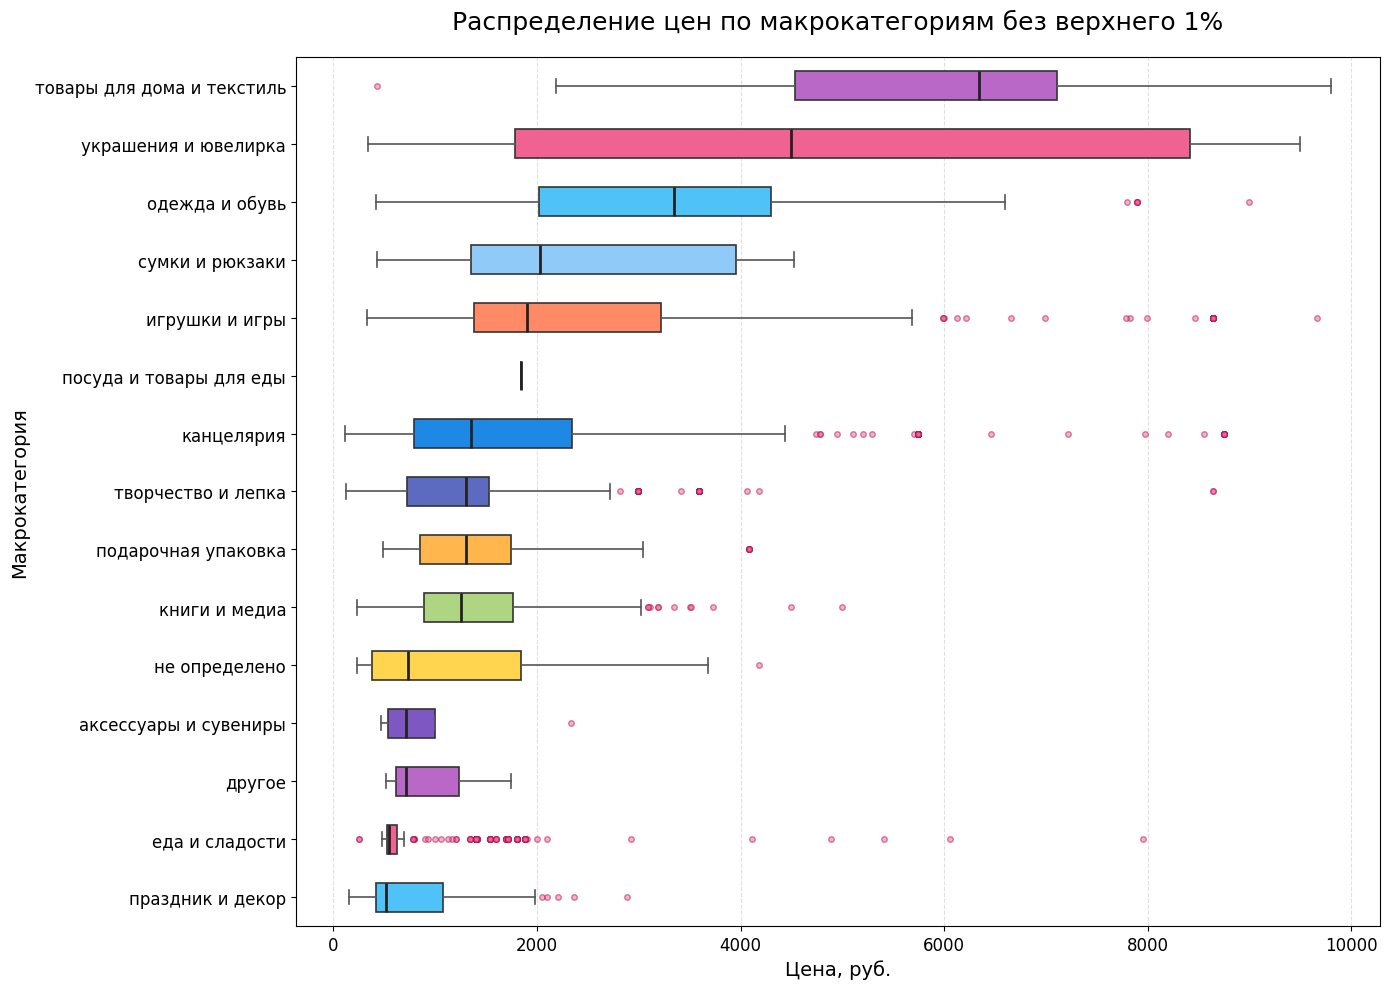

Для визуализации исключён верхний 1% цен. 99-й процентиль: 10141.25 руб.


In [ ]:
# Boxplot цен по макрокатегориям без верхнего 1%, чтобы график был читаемым

price_col = 'price'
q99 = df_clean[price_col].quantile(0.99)

plot_df = df_clean[df_clean[price_col] <= q99].copy()

# Упорядочим категории по медианной цене
category_order = (
    plot_df.groupby('macro_category')[price_col]
    .median()
    .sort_values()
    .index
)

box_data = [
    plot_df.loc[plot_df['macro_category'] == category, price_col].dropna()
    for category in category_order
]

fig, ax = plt.subplots(figsize=(14, 10))

box = ax.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    labels=category_order
)

# Оформление в палитре проекта
for i, patch in enumerate(box['boxes']):
    patch.set_facecolor(smeshariki_palette[i % len(smeshariki_palette)])
    patch.set_edgecolor('#333333')
    patch.set_linewidth(1.2)

for median in box['medians']:
    median.set_color('#222222')
    median.set_linewidth(2)

for whisker in box['whiskers']:
    whisker.set_color('#555555')
    whisker.set_linewidth(1.2)

for cap in box['caps']:
    cap.set_color('#555555')
    cap.set_linewidth(1.2)

for flier in box['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('#F06292')
    flier.set_markeredgecolor('#AD1457')
    flier.set_alpha(0.5)
    flier.set_markersize(4)

ax.set_title(
    'Распределение цен по макрокатегориям без верхнего 1%',
    fontsize=18,
    pad=20
)

ax.set_xlabel(
    'Цена, руб.',
    fontsize=14
)

ax.set_ylabel(
    'Макрокатегория',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=12)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

print(f'Для визуализации исключён верхний 1% цен. 99-й процентиль: {q99:.2f} руб.')

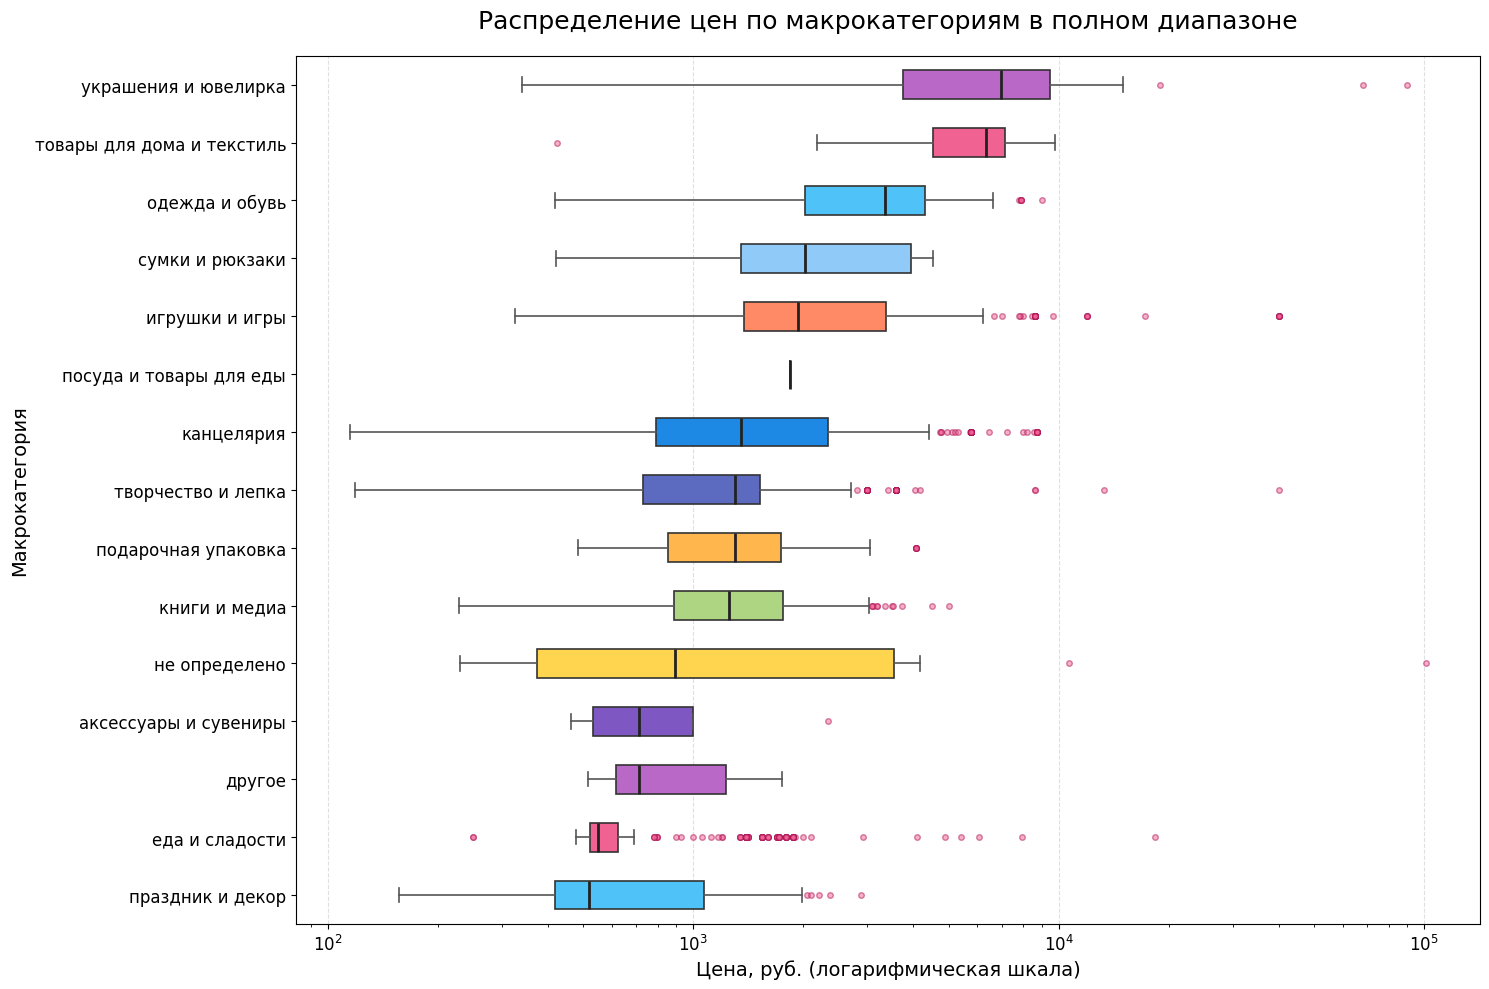

In [ ]:
# Boxplot цен по макрокатегориям в полном диапазоне

price_col = 'price'

plot_df = df_clean.copy()

# Упорядочим категории по медианной цене
category_order = (
    plot_df.groupby('macro_category')[price_col]
    .median()
    .sort_values()
    .index
)

box_data = [
    plot_df.loc[plot_df['macro_category'] == category, price_col].dropna()
    for category in category_order
]

fig, ax = plt.subplots(figsize=(15, 10))

box = ax.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    labels=category_order
)

# Оформление в палитре проекта
for i, patch in enumerate(box['boxes']):
    patch.set_facecolor(smeshariki_palette[i % len(smeshariki_palette)])
    patch.set_edgecolor('#333333')
    patch.set_linewidth(1.2)

for median in box['medians']:
    median.set_color('#222222')
    median.set_linewidth(2)

for whisker in box['whiskers']:
    whisker.set_color('#555555')
    whisker.set_linewidth(1.2)

for cap in box['caps']:
    cap.set_color('#555555')
    cap.set_linewidth(1.2)

for flier in box['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('#F06292')
    flier.set_markeredgecolor('#AD1457')
    flier.set_alpha(0.5)
    flier.set_markersize(4)

# Логарифмическая шкала, чтобы были видны и дешёвые, и дорогие товары
ax.set_xscale('log')

ax.set_title(
    'Распределение цен по макрокатегориям в полном диапазоне',
    fontsize=18,
    pad=20
)

ax.set_xlabel(
    'Цена, руб. (логарифмическая шкала)',
    fontsize=14
)

ax.set_ylabel(
    'Макрокатегория',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=12)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

**Вывод по ценам категорий.**

Наиболее дорогой категорией по медианной цене являются **украшения и ювелирные изделия** — медианная цена составляет 6 950 рублей, что значительно превышает показатели остальных категорий. Также относительно высокие цены характерны для категорий **товары для дома и текстиль** (1 295 рублей), **одежда и обувь** (1 204 рубля) и **сумки и рюкзаки** (1 004 рубля).

Наиболее доступными категориями являются **другое** (176 рублей), **праздник и декор** (292 рубля), **еда и сладости** (321 рубль), **аксессуары и сувениры** (397 рублей) и **творчество и лепка** (401 рубль).

При этом наиболее массовые категории ассортимента - игрушки, канцелярия и товары для творчества, которые относятся преимущественно к низкому и среднему ценовому сегменту. Это свидетельствует о том, что основная часть продукции бренда ориентирована на широкую аудиторию покупателей, тогда как дорогие категории представлены значительно меньшим количеством товаров.

### 3.3. Цены у различных продавцов

Помимо категорий, различия в ценах могут быть связаны с особенностями ассортимента отдельных продавцов. Рассмотрим продавцов с наиболее высокими и наиболее низкими ценами товаров.

In [ ]:
# Цены по условным лицензиатам / продавцам
price_by_licensee = (
    df_clean.groupby('licensee_proxy')
    .agg(
        products_count=('product_id', 'count'),
        mean_price=('discount_price', 'mean'),
        median_price=('discount_price', 'median'),
        min_price=('discount_price', 'min'),
        max_price=('discount_price', 'max')
    )
    .query('products_count >= 5')
    .sort_values('median_price', ascending=False)
    .round(2)
)

display(price_by_licensee.head(30))

,products_count,mean_price,median_price,min_price,max_price
licensee_proxy,,,,,
Ювелирный дом SASONKO,48,"12,156.25","8,900.00",4500,90000
СуперТойз,8,"4,060.12","4,709.00",910,6503
КОНТИНЕНТ,5,"3,431.20","3,190.00",1283,6172
MONETNIK,5,"6,524.40","2,392.00",890,25390
SELA,6,"2,015.83","2,290.00",875,3032
ЧИТАЙ-СТРАНА,5,"2,019.00","1,803.00",908,3190
7 лучиков,7,"1,467.00","1,754.00",450,2439
Играмир,7,"1,550.86","1,653.00",1028,2248
koloboktoys,11,"1,614.55","1,446.00",691,3240


In [ ]:
# Цены по условным лицензиатам / продавцам:
# топ-5 самых дорогих и топ-5 самых доступных по медианной цене

price_by_licensee = (
    df_clean.groupby('licensee_proxy')
    .agg(
        products_count=('licensee_proxy', 'size'),
        mean_price=('price', 'mean'),
        median_price=('price', 'median'),
        min_price=('price', 'min'),
        max_price=('price', 'max')
    )
    .query('products_count >= 5')
    .round(2)
)

top_expensive = (
    price_by_licensee
    .sort_values('median_price', ascending=False)
    .head(5)
)

top_cheap = (
    price_by_licensee
    .sort_values('median_price', ascending=True)
    .head(5)
)

price_extremes = pd.concat(
    [
        top_expensive.assign(price_group='самые дорогие'),
        top_cheap.assign(price_group='самые доступные')
    ]
)

price_extremes_ru = (
    price_extremes
    .reset_index()
    .rename(columns={
        'licensee_proxy': 'Продавец / лицензиат',
        'price_group': 'Группа',
        'products_count': 'Количество товаров',
        'mean_price': 'Средняя цена, ₽',
        'median_price': 'Медианная цена, ₽',
        'min_price': 'Минимальная цена, ₽',
        'max_price': 'Максимальная цена, ₽'
    })
)

# Чтобы сначала шли дорогие, потом доступные
price_extremes_ru['Группа'] = pd.Categorical(
    price_extremes_ru['Группа'],
    categories=['самые дорогие', 'самые доступные'],
    ordered=True
)

price_extremes_ru = price_extremes_ru.sort_values(
    ['Группа', 'Медианная цена, ₽'],
    ascending=[True, False]
)

display(price_extremes_ru)

,Продавец / лицензиат,Количество товаров,"Средняя цена, ₽","Медианная цена, ₽","Минимальная цена, ₽","Максимальная цена, ₽",Группа
0,MONETNIK,5,"26,650.80","10,675.00",3678,101364,самые дорогие
1,Ювелирный дом SASONKO,48,"12,156.25","8,900.00",4500,90000,самые дорогие
2,СуперТойз,8,"7,525.00","8,500.00",2000,12000,самые дорогие
3,TDL Textile,23,"6,155.13","6,399.00",2361,9800,самые дорогие
4,SELA,6,"3,615.67","4,299.00",1799,4299,самые дорогие
9,ТойсМаркет,55,860.20,522.00,119,3848,самые доступные
8,Сима-Ленд Игрушка I,6,522.17,515.00,300,787,самые доступные
7,ПОЗНАЙ МИР ИСТОРИИ,7,425.71,460.00,360,470,самые доступные
6,Sultan Store,34,407.41,404.50,315,520,самые доступные
5,ХАТБЕР-М,26,775.77,398.50,115,4080,самые доступные


In [ ]:
styled_price_extremes = (
    price_extremes_ru.style
    .format({
        'Количество товаров': '{:.0f}',
        'Средняя цена, ₽': '{:,.0f}',
        'Медианная цена, ₽': '{:,.0f}',
        'Минимальная цена, ₽': '{:,.0f}',
        'Максимальная цена, ₽': '{:,.0f}'
    })
    .set_caption('Продавцы / лицензиаты с самыми высокими и низкими медианными ценами')
    .background_gradient(subset=['Медианная цена, ₽'], cmap='Oranges')
    .background_gradient(subset=['Количество товаров'], cmap='Blues')
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#FCE4EC'),
                ('color', '#222222'),
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('border', '1px solid #dddddd'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('padding', '8px'),
                ('font-size', '11px')
            ]
        }
    ])
    .set_properties(subset=['Продавец / лицензиат'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
)

display(styled_price_extremes)

,Продавец / лицензиат,Количество товаров,"Средняя цена, ₽","Медианная цена, ₽","Минимальная цена, ₽","Максимальная цена, ₽",Группа
0,MONETNIK,5,"26,651","10,675","3,678","101,364",самые дорогие
1,Ювелирный дом SASONKO,48,"12,156","8,900","4,500","90,000",самые дорогие
2,СуперТойз,8,"7,525","8,500","2,000","12,000",самые дорогие
3,TDL Textile,23,"6,155","6,399","2,361","9,800",самые дорогие
4,SELA,6,"3,616","4,299","1,799","4,299",самые дорогие
9,ТойсМаркет,55,860,522,119,"3,848",самые доступные
8,Сима-Ленд Игрушка I,6,522,515,300,787,самые доступные
7,ПОЗНАЙ МИР ИСТОРИИ,7,426,460,360,470,самые доступные
6,Sultan Store,34,407,404,315,520,самые доступные
5,ХАТБЕР-М,26,776,398,115,"4,080",самые доступные


**Вывод по ценам продавцов.**

Стоимость товаров заметно различается между продавцами. Наиболее высокие медианные цены наблюдаются у продавцов **MONETNIK** (10 675 рублей), **Ювелирный дом SASONKO** (8 900 рублей), **СуперТойз** (8 500 рублей), **TDL Textile** (6 399 рублей) и **SELA** (4 299 рублей). Высокий уровень цен в основном связан со специализацией на ювелирных изделиях, одежде и текстильной продукции.

Наиболее доступные товары представлены у продавцов **ХАТБЕР-М** (399 рублей), **Sultan Store** (405 рублей), **ПОЗНАЙ МИР ИСТОРИИ** (460 рублей), **Сима-Ленд Игрушка I** (515 рублей) и **ТойсМаркет** (522 рубля). Их ассортимент включает канцелярские товары, игрушки и другую продукцию массового спроса.

Таким образом, различия в ценах между продавцами во многом объясняются составом ассортимента. Продавцы, специализирующиеся на одежде, текстиле и ювелирной продукции, относятся к более дорогому сегменту, тогда как продавцы игрушек, книг и канцелярии ориентированы на массового покупателя.

### 3.4. Ценовые сегменты ассортимента

Для более наглядного анализа товары были распределены по ценовым сегментам. Такой подход позволяет оценить структуру ассортимента с точки зрения доступности продукции и определить, какие ценовые диапазоны преобладают как в целом по бренду, так и внутри отдельных товарных категорий.

,Количество товаров,"Доля, %"
price_segment,,
до 500 ₽,1451,48.99
500–1500 ₽,1287,43.45
1500–5000 ₽,165,5.57
дороже 5000 ₽,59,1.99


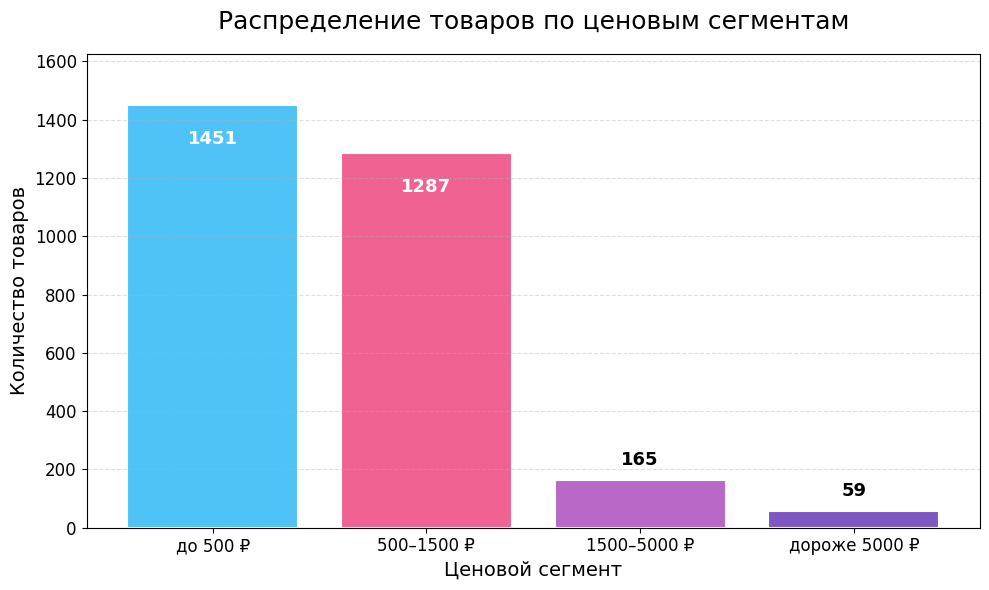

In [ ]:
# Ценовые сегменты

price_segment_counts = (
    df_clean['price_segment']
    .value_counts()
    .sort_index()
)

price_segment_share = (
    df_clean['price_segment']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

price_segment_table = pd.DataFrame({
    'Количество товаров': price_segment_counts,
    'Доля, %': price_segment_share
})

display(price_segment_table)


colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(price_segment_counts))
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    price_segment_counts.index,
    price_segment_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

ax.set_title(
    'Распределение товаров по ценовым сегментам',
    fontsize=18,
    pad=18
)

ax.set_xlabel('Ценовой сегмент', fontsize=14)
ax.set_ylabel('Количество товаров', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

max_value = max(price_segment_counts.values)

for bar in bars:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2

    # Большие столбцы — подпись внутри
    if height > max_value * 0.25:
        ax.text(
            x,
            height - max_value * 0.06,
            int(height),
            ha='center',
            va='top',
            fontsize=13,
            fontweight='bold',
            color='white'
        )
    # Маленькие столбцы — подпись сверху
    else:
        ax.text(
            x,
            height + max_value * 0.025,
            int(height),
            ha='center',
            va='bottom',
            fontsize=13,
            fontweight='bold',
            color='black'
        )

# Чуть увеличиваем верхнюю границу, чтобы верхние подписи точно влезали
ax.set_ylim(0, max_value * 1.12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Ценовые сегменты внутри макрокатегорий
price_segment_by_category = pd.crosstab(
    df_clean['macro_category'],
    df_clean['price_segment'],
    normalize='index'
).mul(100).round(2)

display(price_segment_by_category)

price_segment,до 500 ₽,500–1500 ₽,1500–5000 ₽,дороже 5000 ₽
macro_category,,,,
аксессуары и сувениры,56.25,43.75,0.00,0.00
другое,66.67,33.33,0.00,0.00
еда и сладости,79.78,18.71,1.08,0.43
игрушки и игры,24.35,62.00,11.57,2.07
канцелярия,50.71,44.33,4.79,0.18
книги и медиа,41.77,54.88,3.35,0.00
не определено,46.67,26.67,20.00,6.67
одежда и обувь,13.79,48.28,31.03,6.90
подарочная упаковка,51.00,49.00,0.00,0.00


In [ ]:
# Ценовые сегменты внутри макрокатегорий

price_segment_by_category = pd.crosstab(
    df_clean['macro_category'],
    df_clean['price_segment'],
    normalize='index'
).mul(100).round(2)

# Сортируем категории по доле самого дешевого сегмента, чтобы таблица читалась логичнее
price_segment_by_category = price_segment_by_category.sort_values(
    by=price_segment_by_category.columns[0],
    ascending=False
)

styled_price_segment_by_category = (
    price_segment_by_category.style
    .format('{:.1f}%')
    .background_gradient(cmap='Purples')
    .set_caption('Распределение ценовых сегментов внутри макрокатегорий')
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#FCE4EC'),
                ('color', '#222222'),
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('border', '1px solid #dddddd'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('padding', '8px'),
                ('font-size', '11px'),
                ('text-align', 'center')
            ]
        }
    ])
)

display(styled_price_segment_by_category)

price_segment,до 500 ₽,500–1500 ₽,1500–5000 ₽,дороже 5000 ₽
macro_category,,,,
еда и сладости,79.8%,18.7%,1.1%,0.4%
праздник и декор,73.8%,26.1%,0.0%,0.0%
творчество и лепка,69.5%,29.3%,1.0%,0.2%
другое,66.7%,33.3%,0.0%,0.0%
аксессуары и сувениры,56.2%,43.8%,0.0%,0.0%
подарочная упаковка,51.0%,49.0%,0.0%,0.0%
канцелярия,50.7%,44.3%,4.8%,0.2%
не определено,46.7%,26.7%,20.0%,6.7%
книги и медиа,41.8%,54.9%,3.4%,0.0%


In [ ]:
# Категории с самыми дорогими и самыми доступными товарами по медианной цене
print('Самые дорогие макрокатегории по медианной цене:')
display(price_by_category.sort_values('median_price', ascending=False).head(5))

print('Самые доступные макрокатегории по медианной цене:')
display(price_by_category.sort_values('median_price', ascending=True).head(5))

Самые дорогие макрокатегории по медианной цене:


,products_count,mean_price,median_price,min_price,q25_price,q75_price,max_price
macro_category,,,,,,,
украшения и ювелирка,68,"8,711.53","6,950.00",223,794.25,"9,500.00",90000
товары для дома и текстиль,26,"1,279.23","1,295.00",174,"1,099.25","1,506.25",2544
одежда и обувь,58,"1,781.71","1,203.50",293,697.25,"2,164.50",7900
сумки и рюкзаки,158,"1,016.32","1,003.50",260,846.25,"1,155.25",3246
посуда и товары для еды,2,927.00,927.00,927,927.00,927.00,927


Самые доступные макрокатегории по медианной цене:


,products_count,mean_price,median_price,min_price,q25_price,q75_price,max_price
macro_category,,,,,,,
другое,3,321.33,176.00,100,138.00,432.00,688
праздник и декор,65,412.86,292.00,54,232.00,502.00,1478
еда и сладости,465,422.86,321.00,123,243.00,363.00,6172
аксессуары и сувениры,16,427.81,396.50,63,277.50,632.00,730
творчество и лепка,515,519.68,401.00,53,307.50,540.00,32000


In [ ]:
from IPython.display import display, HTML

# Берём топ-5 дорогих и топ-5 доступных категорий
top_expensive_categories = (
    price_by_category
    .sort_values('median_price', ascending=False)
    .head(5)
    .reset_index()
)

top_cheap_categories = (
    price_by_category
    .sort_values('median_price', ascending=True)
    .head(5)
    .reset_index()
)

# Переименовываем столбцы на русский
rename_price_cols = {
    'macro_category': 'Макрокатегория',
    'products_count': 'Количество товаров',
    'mean_price': 'Средняя цена, ₽',
    'median_price': 'Медианная цена, ₽',
    'min_price': 'Минимальная цена, ₽',
    'max_price': 'Максимальная цена, ₽'
}

top_expensive_categories = top_expensive_categories.rename(columns=rename_price_cols)
top_cheap_categories = top_cheap_categories.rename(columns=rename_price_cols)

# Нумерация строк
top_expensive_categories.index = top_expensive_categories.index + 1
top_cheap_categories.index = top_cheap_categories.index + 1

# Форматирование чисел
def fmt_int(x):
    if pd.isna(x):
        return ''
    return f'{x:,.0f}'.replace(',', ' ')

def fmt_price(x):
    if pd.isna(x):
        return ''
    return f'{x:,.0f}'.replace(',', ' ')

# Общие стили для таблиц
table_styles = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '18px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '12px')
        ]
    },
    {
        'selector': 'th',
        'props': [
            ('background-color', '#FCE4EC'),
            ('color', '#222222'),
            ('font-size', '12px'),
            ('text-align', 'center'),
            ('border', '1px solid #dddddd'),
            ('padding', '8px')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('border', '1px solid #dddddd'),
            ('padding', '8px'),
            ('font-size', '11px'),
            ('text-align', 'center')
        ]
    }
]

# Дорогие категории
styled_expensive_categories = (
    top_expensive_categories.style
    .format({
        'Количество товаров': fmt_int,
        'Средняя цена, ₽': fmt_price,
        'Медианная цена, ₽': fmt_price,
        'Минимальная цена, ₽': fmt_price,
        'Максимальная цена, ₽': fmt_price
    })
    .set_caption('Топ-5 самых дорогих макрокатегорий по медианной цене')
    .background_gradient(subset=['Медианная цена, ₽'], cmap='Oranges')
    .background_gradient(subset=['Количество товаров'], cmap='Blues')
    .set_table_styles(table_styles)
    .set_properties(subset=['Макрокатегория'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
)

# Доступные категории
styled_cheap_categories = (
    top_cheap_categories.style
    .format({
        'Количество товаров': fmt_int,
        'Средняя цена, ₽': fmt_price,
        'Медианная цена, ₽': fmt_price,
        'Минимальная цена, ₽': fmt_price,
        'Максимальная цена, ₽': fmt_price
    })
    .set_caption('Топ-5 самых доступных макрокатегорий по медианной цене')
    .background_gradient(subset=['Медианная цена, ₽'], cmap='Greens')
    .background_gradient(subset=['Количество товаров'], cmap='Blues')
    .set_table_styles(table_styles)
    .set_properties(subset=['Макрокатегория'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
)

display(styled_expensive_categories)
display(styled_cheap_categories)

,Макрокатегория,Количество товаров,"Средняя цена, ₽","Медианная цена, ₽","Минимальная цена, ₽",q25_price,q75_price,"Максимальная цена, ₽"
1,украшения и ювелирка,68,8 712,6 950,223,794.250000,9500.000000,90 000
2,товары для дома и текстиль,26,1 279,1 295,174,1099.250000,1506.250000,2 544
3,одежда и обувь,58,1 782,1 204,293,697.250000,2164.500000,7 900
4,сумки и рюкзаки,158,1 016,1 004,260,846.250000,1155.250000,3 246
5,посуда и товары для еды,2,927,927,927,927.000000,927.000000,927


,Макрокатегория,Количество товаров,"Средняя цена, ₽","Медианная цена, ₽","Минимальная цена, ₽",q25_price,q75_price,"Максимальная цена, ₽"
1,другое,3,321,176,100,138.000000,432.000000,688
2,праздник и декор,65,413,292,54,232.000000,502.000000,1 478
3,еда и сладости,465,423,321,123,243.000000,363.000000,6 172
4,аксессуары и сувениры,16,428,396,63,277.500000,632.000000,730
5,творчество и лепка,515,520,401,53,307.500000,540.000000,32 000


**Вывод по ценовым сегментам.**

Почти весь ассортимент бренда относится к доступным ценовым сегментам. На товары стоимостью **до 500 рублей** приходится **48,99%** ассортимента, а ещё **43,45%** товаров находятся в диапазоне **от 500 до 1500 рублей**. Таким образом, более **92% всех товаров** стоят менее 1500 рублей.

Наиболее доступными категориями являются **еда и сладости** (79,8% товаров дешевле 500 рублей), **праздник и декор** (73,8%) и **творчество и лепка** (69,5%). Напротив, категории **одежда и обувь**, **товары для дома и текстиль** и особенно **украшения и ювелирка** характеризуются более высокой долей дорогих товаров.

Особенно выделяется категория **украшения и ювелирка**, где более половины товаров (55,9%) относятся к сегменту дороже 5000 рублей. В то же время массовые категории ассортимента - игрушки, книги, канцелярия, товары для творчества и сладости - представлены преимущественно в доступном и среднем ценовом диапазоне.

**Вывод по ценовой аналитике.**

Распределение цен имеет выраженную правостороннюю асимметрию: большинство товаров относится к доступным ценовым сегментам, однако в ассортименте присутствуют отдельные дорогостоящие позиции. Средняя цена со скидкой составляет 960 рублей, тогда как медианная - 516 рублей, поэтому для анализа более показательна именно медиана.

Наиболее дорогой категорией являются **украшения и ювелирка**, а наиболее доступной - категория **другое**. Более 92% товаров стоят менее 1500 рублей, что говорит об ориентации бренда на массового покупателя. При этом наличие одежды, товаров для дома и ювелирной продукции формирует отдельный более дорогой сегмент ассортимента.

In [ ]:
median_price = df_clean['discount_price'].median()
mean_price = df_clean['discount_price'].mean()

print(f'Средняя цена со скидкой: {mean_price:.2f} руб.')
print(f'Медианная цена со скидкой: {median_price:.2f} руб.')

print('\nСамая дорогая категория по медианной цене:')
print(price_by_category.sort_values('median_price', ascending=False).head(1).index[0])

print('\nСамая доступная категория по медианной цене:')
print(price_by_category.sort_values('median_price', ascending=True).head(1).index[0])

Средняя цена со скидкой: 959.57 руб.
Медианная цена со скидкой: 516.00 руб.

Самая дорогая категория по медианной цене:
украшения и ювелирка

Самая доступная категория по медианной цене:
другое


## 4. Пользовательская активность

Отзывы и рейтинги используются как косвенный показатель интереса покупателей. Важно учитывать, что отсутствие отзывов не означает плохое качество товара: часть карточек может быть новой, нишевой или просто менее заметной для покупателей.


### 4.1. Общая активность пользователей

Сначала рассмотрим общие показатели пользовательской активности: количество товаров с отзывами, суммарное число отзывов и распределение рейтингов. Это позволит оценить общий уровень вовлечённости покупателей и понять, насколько активно пользователи взаимодействуют с товарами бренда.

In [ ]:
# Общая статистика по отзывам
activity_overview = pd.Series({
    'Всего товаров': len(df_clean),
    'Товаров с отзывами': int(df_clean['has_reviews'].sum()),
    'Доля товаров с отзывами, %': round(df_clean['has_reviews'].mean() * 100, 2),
    'Всего отзывов': int(df_clean['reviews_count'].sum()),
    'Медиана отзывов': df_clean['reviews_count'].median(),
    'Максимум отзывов': df_clean['reviews_count'].max(),
    'Средний рейтинг среди товаров с отзывами': df_clean['rating_active'].mean(),
    'Медианный рейтинг среди товаров с отзывами': df_clean['rating_active'].median()
})

display(activity_overview.to_frame('value'))

,value
Всего товаров,"2,962.00"
Товаров с отзывами,646.00
"Доля товаров с отзывами, %",21.81
Всего отзывов,"276,154.00"
Медиана отзывов,0.00
Максимум отзывов,"18,880.00"
Средний рейтинг среди товаров с отзывами,4.84
Медианный рейтинг среди товаров с отзывами,5.00


In [ ]:
# Общая статистика по отзывам и рейтингам

activity_overview = pd.DataFrame({
    'Показатель': [
        'Всего товаров',
        'Товаров с отзывами',
        'Доля товаров с отзывами, %',
        'Всего отзывов',
        'Медианное количество отзывов на товар',
        'Максимальное количество отзывов у товара',
        'Средний рейтинг среди товаров с отзывами',
        'Медианный рейтинг среди товаров с отзывами'
    ],
    'Значение': [
        len(df_clean),
        int(df_clean['has_reviews'].sum()),
        round(df_clean['has_reviews'].mean() * 100, 2),
        int(df_clean['reviews_count'].sum()),
        df_clean['reviews_count'].median(),
        int(df_clean['reviews_count'].max()),
        round(df_clean['rating_active'].mean(), 2),
        round(df_clean['rating_active'].median(), 2)
    ]
})

# Форматирование значений
def format_activity_value(row):
    indicator = row['Показатель']
    value = row['Значение']

    if pd.isna(value):
        return ''

    if 'Доля' in indicator:
        return f'{value:.2f}%'.replace('.', ',')

    if 'рейтинг' in indicator.lower():
        return f'{value:.2f}'.replace('.', ',')

    return f'{value:,.0f}'.replace(',', ' ')

activity_overview['Значение'] = activity_overview.apply(
    format_activity_value,
    axis=1
)

styled_activity_overview = (
    activity_overview.style
    .set_caption('Общая статистика по отзывам и рейтингам')
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#FCE4EC'),
                ('color', '#222222'),
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('border', '1px solid #dddddd'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('padding', '8px'),
                ('font-size', '12px')
            ]
        }
    ])
    .set_properties(subset=['Показатель'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
    .set_properties(subset=['Значение'], **{
        'text-align': 'center'
    })
)

display(styled_activity_overview)

,Показатель,Значение
0,Всего товаров,2 962
1,Товаров с отзывами,646
2,"Доля товаров с отзывами, %","21,81%"
3,Всего отзывов,276 154
4,Медианное количество отзывов на товар,0
5,Максимальное количество отзывов у товара,18 880
6,Средний рейтинг среди товаров с отзывами,"4,84"
7,Медианный рейтинг среди товаров с отзывами,"5,00"


**Вывод по общей пользовательской активности.**

Из 2962 товаров отзывы имеют 646 товаров, то есть 21,81% датасета. При этом суммарно собрано 276 154 отзыва, а максимальное число отзывов у одного товара достигает 18 880. Это показывает, что пользовательская активность распределена неравномерно: большинство товаров не имеет отзывов, но отдельные популярные позиции собирают очень большой отклик. Среди товаров с отзывами оценки высокие: средний рейтинг составляет 4,84, а медианный - 5,00.

### 4.2. Пользовательская активность по макрокатегориям

Далее сравним макрокатегории по суммарному количеству отзывов и доле товаров с отзывами. Это позволяет понять, какие направления ассортимента вызывают наибольший отклик покупателей.

In [ ]:
# Активность по макрокатегориям
activity_by_category = (
    df_clean.groupby('macro_category')
    .agg(
        products_count=('product_id', 'count'),
        products_with_reviews=('has_reviews', 'sum'),
        total_reviews=('reviews_count', 'sum'),
        mean_reviews=('reviews_count', 'mean'),
        median_reviews=('reviews_count', 'median'),
        max_reviews=('reviews_count', 'max'),
        mean_rating=('rating_active', 'mean'),
        median_rating=('rating_active', 'median')
    )
    .sort_values('total_reviews', ascending=False)
)

activity_by_category['share_with_reviews_percent'] = (
    activity_by_category['products_with_reviews'] / activity_by_category['products_count'] * 100
).round(2)

activity_by_category = activity_by_category.round(2)
display(activity_by_category)

,products_count,products_with_reviews,total_reviews,mean_reviews,median_reviews,max_reviews,mean_rating,median_rating,share_with_reviews_percent
macro_category,,,,,,,,,
украшения и ювелирка,68,20,"68,755.00","1,011.10",0.00,"5,435.00",4.86,4.90,29.41
книги и медиа,328,82,"67,025.00",204.34,0.00,"18,880.00",4.86,5.00,25.00
игрушки и игры,579,123,"36,770.00",63.51,0.00,"4,628.00",4.82,4.90,21.24
праздник и декор,65,61,"32,461.00",499.40,11.00,"9,006.00",4.85,4.90,93.85
еда и сладости,465,102,"21,012.00",45.19,0.00,"5,286.00",4.84,5.00,21.94
не определено,15,9,"21,005.00","1,400.33",430.00,"7,168.00",4.96,5.00,60.00
канцелярия,564,78,"16,766.00",29.73,0.00,"2,453.00",4.89,4.90,13.83
творчество и лепка,515,42,"3,083.00",5.99,0.00,395.00,4.59,4.90,8.16
подарочная упаковка,100,9,"3,046.00",30.46,0.00,"1,039.00",4.78,4.80,9.00


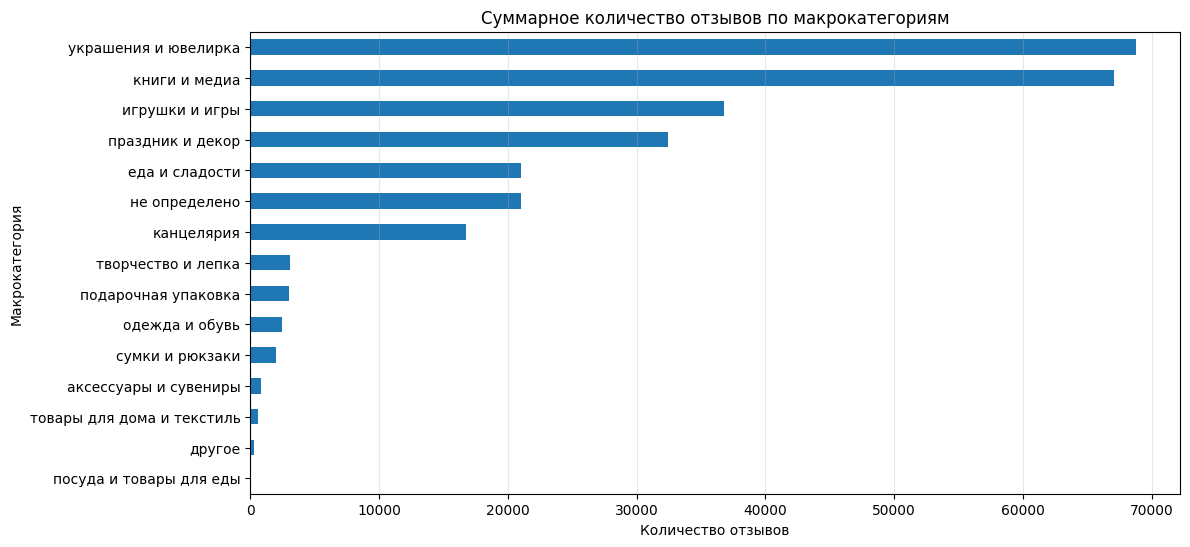

In [ ]:
# График: суммарные отзывы по категориям
plt.figure(figsize=(12, 6))
activity_by_category['total_reviews'].sort_values().plot(kind='barh')
plt.title('Суммарное количество отзывов по макрокатегориям')
plt.xlabel('Количество отзывов')
plt.ylabel('Макрокатегория')
plt.grid(axis='x', alpha=0.3)
plt.show()

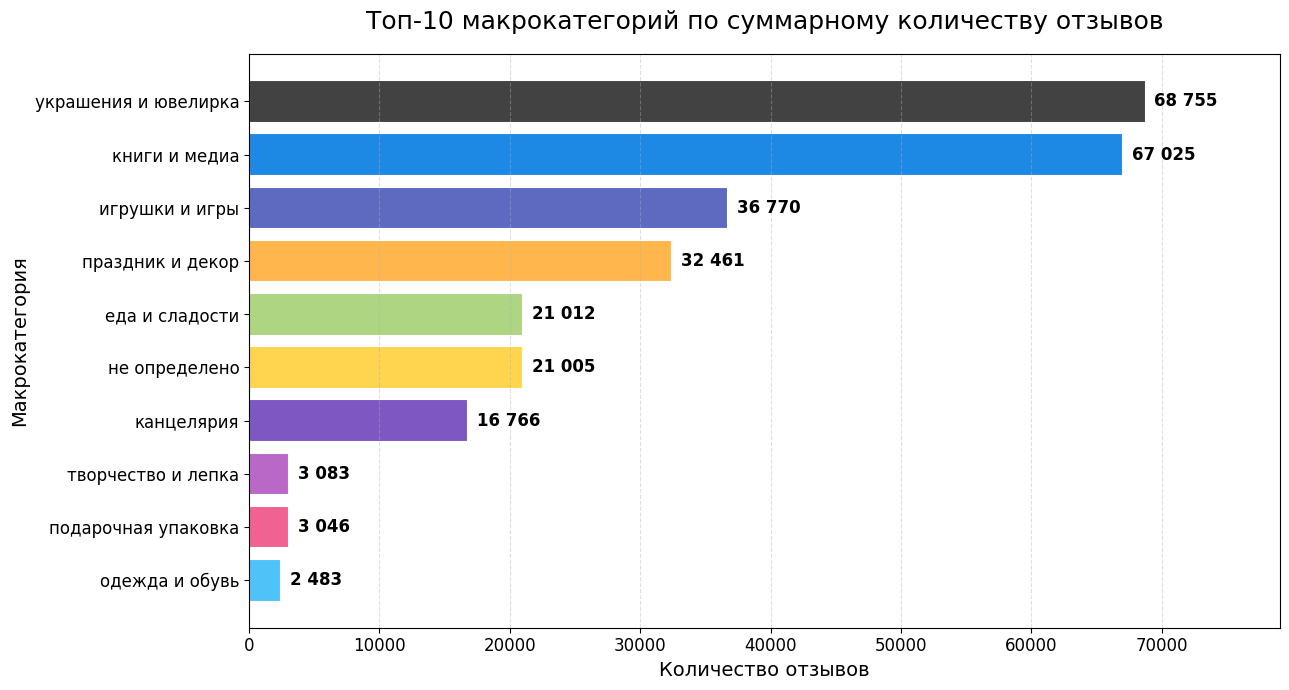

In [ ]:
# График: суммарные отзывы по категориям

reviews_plot = (
    activity_by_category['total_reviews']
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(reviews_plot))
]

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    reviews_plot.index,
    reviews_plot.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

ax.set_title(
    'Топ-10 макрокатегорий по суммарному количеству отзывов',
    fontsize=18,
    pad=18
)

ax.set_xlabel(
    'Количество отзывов',
    fontsize=14
)

ax.set_ylabel(
    'Макрокатегория',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=12)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

max_value = max(reviews_plot.values)

# Подписи значений справа от столбцов
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_value * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,}'.replace(',', ' '),
        va='center',
        fontsize=12,
        fontweight='bold'
    )

ax.set_xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

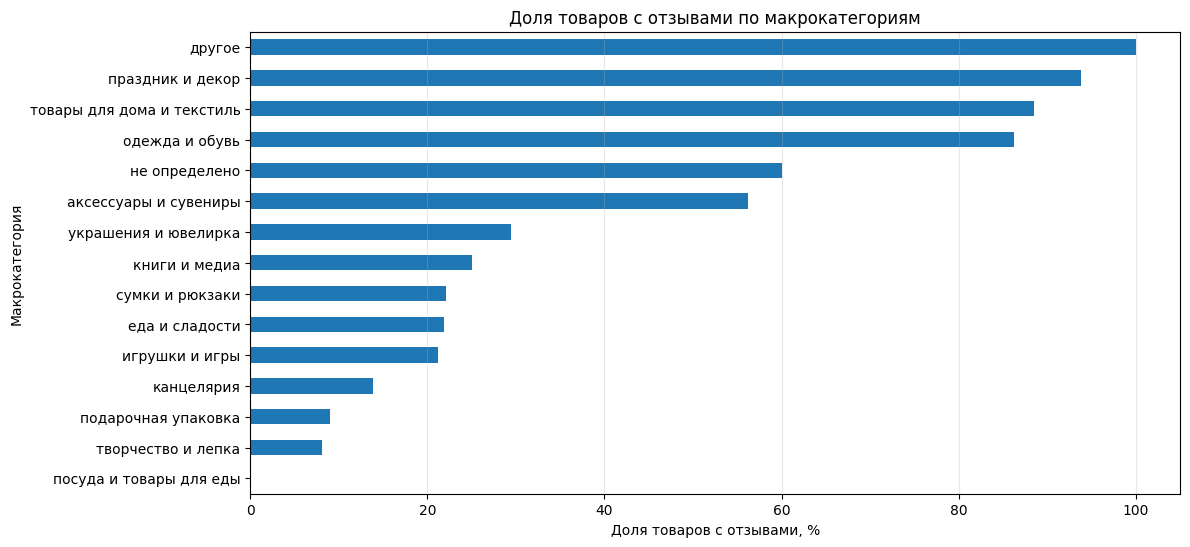

In [ ]:
# График: доля товаров с отзывами по категориям
plt.figure(figsize=(12, 6))
activity_by_category['share_with_reviews_percent'].sort_values().plot(kind='barh')
plt.title('Доля товаров с отзывами по макрокатегориям')
plt.xlabel('Доля товаров с отзывами, %')
plt.ylabel('Макрокатегория')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Вывод по активности макрокатегорий.**

Больше всего отзывов собрали категории «Украшения и ювелирка» - 68,8 тыс. отзывов, «Книги и медиа» - 67,0 тыс. отзывов и «Игрушки и игры» - 36,8 тыс. отзывов. При этом по доле товаров с отзывами лидируют «Другое» (100%), «Праздник и декор» (93,85%), «Товары для дома и текстиль» (88,46%) и «Одежда и обувь» (86,21%). Это показывает, что лидерство по общему числу отзывов и по доле товаров с отзывами не всегда совпадает.

### 4.3. Рейтинг товаров по макрокатегориям

Рейтинг анализируется только для товаров с отзывами, так как отсутствие отзывов не позволяет оценить пользовательское восприятие товара. В этом блоке сравниваются средние и медианные рейтинги по макрокатегориям.

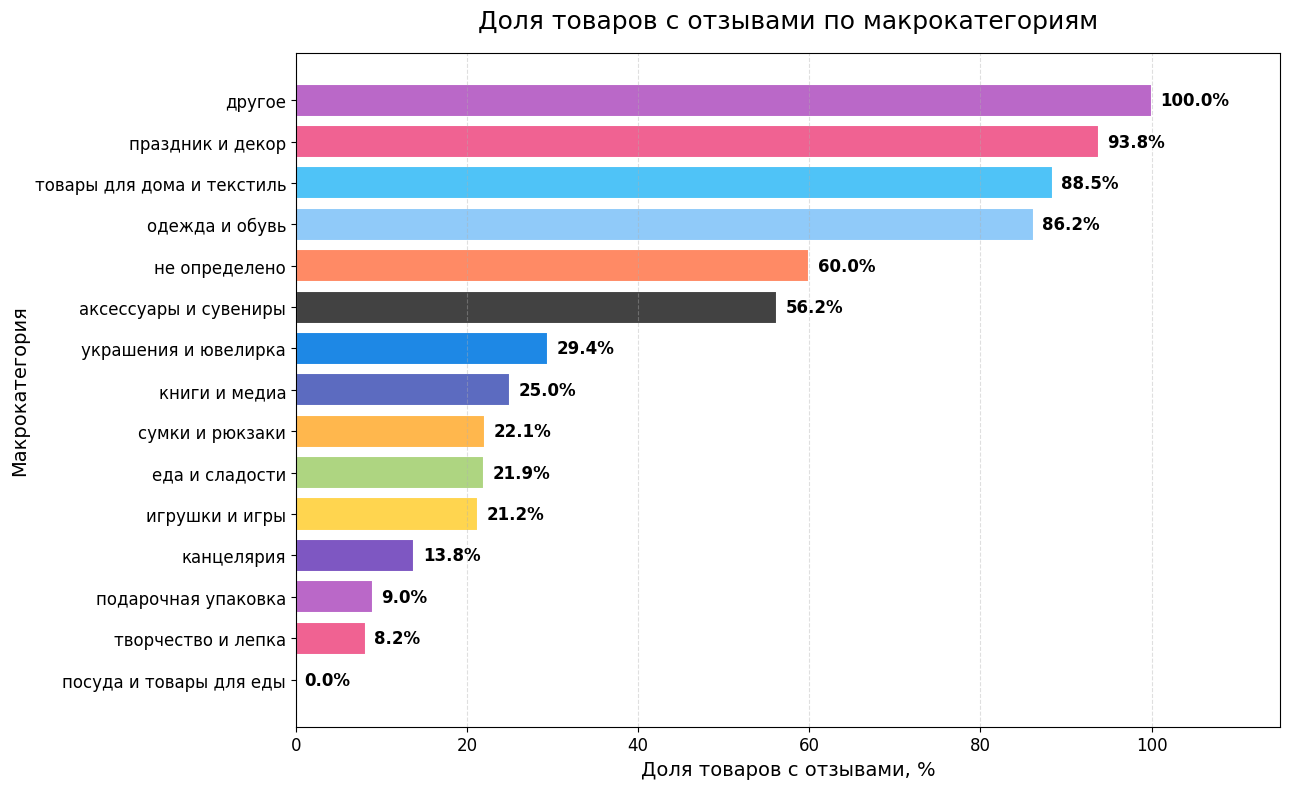

In [ ]:
# График: доля товаров с отзывами по категориям

reviews_share_plot = (
    activity_by_category['share_with_reviews_percent']
    .sort_values()
)

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(reviews_share_plot))
]

fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(
    reviews_share_plot.index,
    reviews_share_plot.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

ax.set_title(
    'Доля товаров с отзывами по макрокатегориям',
    fontsize=18,
    pad=18
)

ax.set_xlabel(
    'Доля товаров с отзывами, %',
    fontsize=14
)

ax.set_ylabel(
    'Макрокатегория',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=12)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

max_value = max(reviews_share_plot.values)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_value * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

ax.set_xlim(0, max_value * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# Средний и медианный рейтинг по категориям среди товаров с отзывами
rating_by_category = (
    df_clean[df_clean['has_reviews']]
    .groupby('macro_category')
    .agg(
        products_with_reviews=('product_id', 'count'),
        mean_rating=('rating', 'mean'),
        median_rating=('rating', 'median'),
        min_rating=('rating', 'min'),
        max_rating=('rating', 'max')
    )
    .query('products_with_reviews >= 3')
    .sort_values('median_rating', ascending=False)
    .round(2)
)

display(rating_by_category)

,products_with_reviews,mean_rating,median_rating,min_rating,max_rating
macro_category,,,,,
книги и медиа,82,4.86,5.00,3.00,5.00
еда и сладости,102,4.84,5.00,3.00,5.00
сумки и рюкзаки,35,4.93,5.00,4.30,5.00
товары для дома и текстиль,23,4.92,5.00,4.60,5.00
не определено,9,4.96,5.00,4.90,5.00
игрушки и игры,123,4.82,4.90,1.00,5.00
творчество и лепка,42,4.59,4.90,1.00,5.00
канцелярия,78,4.89,4.90,4.20,5.00
аксессуары и сувениры,9,4.94,4.90,4.90,5.00


In [ ]:
# Средний и медианный рейтинг по категориям среди товаров с отзывами

rating_by_category = (
    df_clean[df_clean['has_reviews']]
    .groupby('macro_category')
    .agg(
        products_with_reviews=('macro_category', 'size'),
        mean_rating=('rating', 'mean'),
        median_rating=('rating', 'median'),
        min_rating=('rating', 'min'),
        max_rating=('rating', 'max')
    )
    .query('products_with_reviews >= 3')
    .sort_values('median_rating', ascending=False)
    .round(2)
)

rating_by_category_ru = (
    rating_by_category
    .reset_index()
    .rename(columns={
        'macro_category': 'Макрокатегория',
        'products_with_reviews': 'Товаров с отзывами',
        'mean_rating': 'Средний рейтинг',
        'median_rating': 'Медианный рейтинг',
        'min_rating': 'Минимальный рейтинг',
        'max_rating': 'Максимальный рейтинг'
    })
)

rating_by_category_ru.index = rating_by_category_ru.index + 1

styled_rating_by_category = (
    rating_by_category_ru.style
    .format({
        'Товаров с отзывами': '{:.0f}',
        'Средний рейтинг': '{:.2f}',
        'Медианный рейтинг': '{:.2f}',
        'Минимальный рейтинг': '{:.2f}',
        'Максимальный рейтинг': '{:.2f}'
    })
    .set_caption('Рейтинг товаров по макрокатегориям')
    .background_gradient(subset=['Медианный рейтинг'], cmap='Purples')
    .background_gradient(subset=['Товаров с отзывами'], cmap='Blues')
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#FCE4EC'),
                ('color', '#222222'),
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('border', '1px solid #dddddd'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('padding', '8px'),
                ('font-size', '11px'),
                ('text-align', 'center')
            ]
        }
    ])
    .set_properties(subset=['Макрокатегория'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
)

display(styled_rating_by_category)

,Макрокатегория,Товаров с отзывами,Средний рейтинг,Медианный рейтинг,Минимальный рейтинг,Максимальный рейтинг
1,книги и медиа,82,4.86,5.00,3.00,5.00
2,еда и сладости,102,4.84,5.00,3.00,5.00
3,сумки и рюкзаки,35,4.93,5.00,4.30,5.00
4,товары для дома и текстиль,23,4.92,5.00,4.60,5.00
5,не определено,9,4.96,5.00,4.90,5.00
6,игрушки и игры,123,4.82,4.90,1.00,5.00
7,творчество и лепка,42,4.59,4.90,1.00,5.00
8,канцелярия,78,4.89,4.90,4.20,5.00
9,аксессуары и сувениры,9,4.94,4.90,4.90,5.00
10,одежда и обувь,50,4.91,4.90,4.50,5.00


**Вывод по рейтингам.**

Медианные рейтинги почти во всех категориях находятся в диапазоне 4,8-5,0. Наиболее высокие медианные оценки получили «Книги и медиа», «Еда и сладости», «Сумки и рюкзаки» и «Товары для дома и текстиль» - по 5,00. Это говорит о том, что товары с отзывами в целом оцениваются покупателями положительно.

### 4.4. Товары с наибольшим количеством отзывов

Отдельно рассмотрим карточки товаров, которые получили максимальный пользовательский отклик. Это помогает выявить не только активные категории, но и конкретные наиболее заметные позиции внутри ассортимента.

In [ ]:
# Топ товаров по отзывам
top_reviewed_products = df_clean.sort_values('reviews_count', ascending=False)[
    ['product_name', 'brand', 'seller', 'macro_category', 'discount_price', 'rating', 'reviews_count', 'link']
].head(20)

display(top_reviewed_products)

,product_name,brand,seller,macro_category,discount_price,rating,reviews_count,link
2155,Свитбокс Смешарики с 2мя брелками и мармеладом...,Конфитрейд,Уголок сказки,книги и медиа,791,4.80,"18,880.00",https://www.wildberries.ru/catalog/168809813/d...
2149,Свитбокс Смешарики с 2мя брелками и мармеладом...,Конфитрейд,Уголок сказки,книги и медиа,121,4.80,"18,880.00",https://www.wildberries.ru/catalog/168848412/d...
2276,Воздушные шарики для детей Смешарики Нюша и Ба...,Дон Баллон,Улетное настроение,праздник и декор,817,4.90,"9,006.00",https://www.wildberries.ru/catalog/962118117/d...
2252,Воздушные шарики для детей Смешарики Крош Ежик...,Дон Баллон,Улетное настроение,праздник и декор,744,4.90,"9,006.00",https://www.wildberries.ru/catalog/488878672/d...
2899,SCANDIC Смешарики яблочные драже 18 штук,не указан,ИП Тогузаев Тимур С...,не определено,1517,4.90,"7,168.00",https://www.ozon.ru/product/scandic-smeshariki...
2883,SCANDIC Смешарики яблочный 4 штуки,не указан,ИП Тогузаев Тимур С...,не определено,450,4.90,"7,168.00",https://www.ozon.ru/product/scandic-smeshariki...
2852,"Игрушка-подвеска ""Мякиши"" Пин Смешарики",Мякиши,МЯКИШИ фабрика игру...,украшения и ювелирка,367,4.90,"5,435.00",https://www.ozon.ru/product/igrushka-podveska-...
2855,"Игрушка-подвеска ""Мякиши"" Крош, Лосяш, Пин, См...",Мякиши,МЯКИШИ фабрика игру...,украшения и ювелирка,806,4.90,"5,435.00",https://www.ozon.ru/product/igrushka-podveska-...
2857,"Игрушка-подвеска ""Мякиши"" Нюша, Копатыч, Бараш...",Мякиши,МЯКИШИ фабрика игру...,украшения и ювелирка,792,4.90,"5,435.00",https://www.ozon.ru/product/igrushka-podveska-...
2844,"Игрушка-подвеска ""Мякиши"" Ёжик Смешарики",Мякиши,МЯКИШИ фабрика игру...,украшения и ювелирка,368,4.90,"5,435.00",https://www.ozon.ru/product/igrushka-podveska-...


**Вывод по самым обсуждаемым товарам.**

Наибольшее количество отзывов получили отдельные товары из категорий «Книги и медиа», «Праздник и декор», «Еда и сладости» и товары бренда «Мякиши». Максимальное значение составляет 18 880 отзывов. Это подтверждает, что пользовательский отклик концентрируется вокруг отдельных популярных карточек, а не распределяется равномерно по всему ассортименту.

### 4.5. Связь цены и пользовательской активности

Проверяем, есть ли связь между:

- ценой со скидкой;
- количеством отзывов;
- логарифмом количества отзывов;
- рейтингом;
- рейтингом продавца.

Для основного вывода лучше использовать корреляцию Спирмена, потому что цены и отзывы обычно распределены не нормально и имеют сильные выбросы.

In [ ]:
corr_cols = [col for col in ['discount_price', 'reviews_count', 'log_reviews', 'rating_active', 'seller_rating', 'discount_percent', 'total_quantity'] if col in df_clean.columns]

corr_spearman = df_clean[corr_cols].corr(method='spearman').round(3)
corr_pearson = df_clean[corr_cols].corr(method='pearson').round(3)

print('Корреляция Спирмена')
display(corr_spearman)

print('Корреляция Пирсона')
display(corr_pearson)

Корреляция Спирмена


,discount_price,reviews_count,log_reviews,rating_active,seller_rating,discount_percent,total_quantity
discount_price,1.00,-0.10,-0.10,0.06,-0.17,-0.12,-0.20
reviews_count,-0.10,1.00,1.00,-0.27,0.51,0.01,0.17
log_reviews,-0.10,1.00,1.00,-0.27,0.51,0.01,0.17
rating_active,0.06,-0.27,-0.27,1.00,-0.06,-0.24,0.04
seller_rating,-0.17,0.51,0.51,-0.06,1.00,-0.09,0.25
discount_percent,-0.12,0.01,0.01,-0.24,-0.09,1.00,-0.12
total_quantity,-0.20,0.17,0.17,0.04,0.25,-0.12,1.00


Корреляция Пирсона


,discount_price,reviews_count,log_reviews,rating_active,seller_rating,discount_percent,total_quantity
discount_price,1.00,-0.01,-0.04,0.04,-0.03,-0.25,-0.02
reviews_count,-0.01,1.00,0.52,0.04,0.10,-0.00,0.19
log_reviews,-0.04,0.52,1.00,0.14,0.46,0.01,0.27
rating_active,0.04,0.04,0.14,1.00,0.15,-0.04,0.06
seller_rating,-0.03,0.10,0.46,0.15,1.00,-0.09,0.24
discount_percent,-0.25,-0.00,0.01,-0.04,-0.09,1.00,-0.14
total_quantity,-0.02,0.19,0.27,0.06,0.24,-0.14,1.00


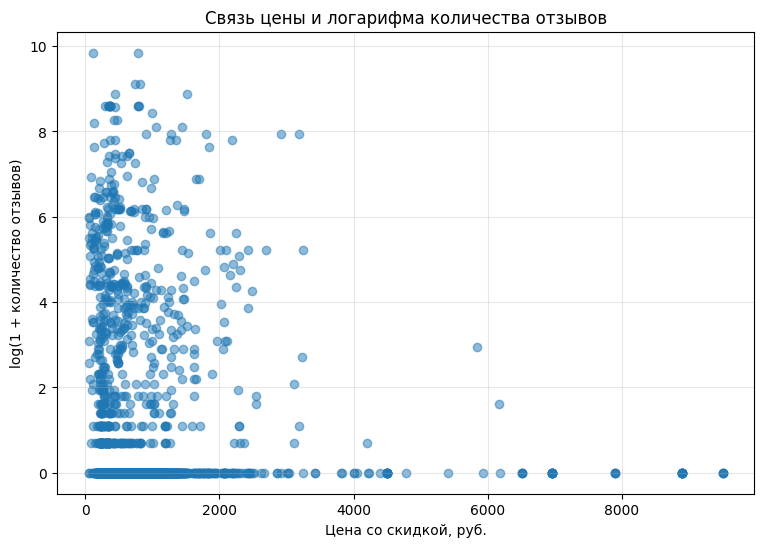

In [ ]:
# Визуализация связи цены и отзывов
plot_df = df_clean.copy()
plot_df = plot_df[(plot_df['discount_price'] <= q99)]

plt.figure(figsize=(9, 6))
plt.scatter(plot_df['discount_price'], plot_df['log_reviews'], alpha=0.5)
plt.title('Связь цены и логарифма количества отзывов')
plt.xlabel('Цена со скидкой, руб.')
plt.ylabel('log(1 + количество отзывов)')
plt.grid(alpha=0.3)
plt.show()

**Вывод по связи цены и активности.**

Корреляция Спирмена между ценой со скидкой и количеством отзывов составляет -0,10, что указывает на очень слабую отрицательную связь. Это значит, что цена почти не объясняет количество отзывов. Более заметная связь наблюдается между рейтингом продавца и количеством отзывов: коэффициент Спирмена составляет 0,51. Следовательно, пользовательская активность сильнее связана не с ценой товара, а с характеристиками продавца и популярностью конкретных карточек.

**Вывод по пользовательской активности.**

Пользовательская активность распределена неравномерно: отзывы имеют только 21,8% товаров, однако суммарное количество отзывов превышает 276 тысяч. Наибольшее число отзывов собрали категории **«Украшения и ювелирка»**, **«Книги и медиа»** и **«Игрушки и игры»**. При этом лидеры по количеству отзывов лишь частично совпадают с наиболее многочисленными категориями ассортимента.

Наибольший пользовательский отклик получили отдельные товары из категорий **«Книги и медиа»**, **«Праздник и декор»**, **«Еда и сладости»**, а максимальное количество отзывов у одного товара составило **18 880**.

Анализ корреляции показал отсутствие заметной связи между ценой товара и количеством отзывов (коэффициент Спирмена составляет **-0,103**). Это позволяет предположить, что популярность товаров определяется не столько ценой, сколько особенностями категории, узнаваемостью бренда и востребованностью конкретных товаров.

Рейтинг анализировался только для товаров с отзывами, поскольку отсутствие отзывов не позволяет объективно оценить отношение покупателей к товару. В целом товары бренда получают высокие оценки: медианный рейтинг составляет **5 баллов**.

In [ ]:
print('Категория с максимальным суммарным числом отзывов:')
print(activity_by_category.sort_values('total_reviews', ascending=False).head(1).index[0])


if 'discount_price' in corr_spearman.index and 'log_reviews' in corr_spearman.columns:
    print('\nКорреляция Спирмена между ценой и log_reviews:')
    print(corr_spearman.loc['discount_price', 'log_reviews'])

Категория с максимальным суммарным числом отзывов:
украшения и ювелирка

Корреляция Спирмена между ценой и log_reviews:
-0.103


## 5. Самый популярный смешарик

В этом блоке по названиям товаров выделяются упоминания персонажей. Такой анализ не показывает абсолютную популярность героев у всех зрителей, но помогает понять, какие персонажи чаще используются в товарных карточках и какие из них собирают больше пользовательского внимания.


In [ ]:
import re

characters_patterns = {
    'Крош': [r'(?<![а-яё])крош(?![а-яё])', r'крошик'],
    'Нюша': [r'нюш'],
    'Бараш': [r'бараш'],
    'Ёжик': [r'ежик', r'ёжик'],
    'Пин': [r'(?<![а-яё])пин(?![а-яё])'],
    'Лосяш': [r'лосяш'],
    'Совунья': [r'совун'],
    'Кар-Карыч': [r'кар[- ]?карыч', r'карыч'],
    'Копатыч': [r'копатыч'],
    'Биби': [r'(?<![а-яё])биби(?![а-яё])']
}

def find_characters(product_name):
    text = str(product_name).lower()
    text_norm = text.replace('ё', 'е')

    found = []

    for character, patterns in characters_patterns.items():
        for pattern in patterns:
            pattern_norm = pattern.replace('ё', 'е')
            if re.search(pattern_norm, text_norm):
                found.append(character)
                break

    if len(found) == 0:
        return ['персонаж не указан']

    return found

df_clean['characters'] = df_clean['product_name'].apply(find_characters)

character_df = df_clean.explode('characters').copy()

character_summary = (
    character_df[character_df['characters'] != 'персонаж не указан']
    .groupby('characters')
    .agg(
        products_count=('product_id', 'count'),
        total_reviews=('reviews_count', 'sum'),
        median_reviews=('reviews_count', 'median'),
        median_price=('discount_price', 'median'),
        mean_rating=('rating_active', 'mean')
    )
    .sort_values('products_count', ascending=False)
    .round(2)
)

display(character_summary)

print('Товаров без явного персонажа в названии:', (character_df['characters'] == 'персонаж не указан').sum())


,products_count,total_reviews,median_reviews,median_price,mean_rating
characters,,,,,
Крош,99,"32,768.00",0.00,790.00,4.88
Нюша,82,"36,158.00",0.00,713.50,4.91
Ёжик,45,"27,416.00",12.00,795.00,4.92
Бараш,20,"25,022.00",20.50,"1,316.50",4.91
Пин,16,"12,436.00",2.50,"1,106.50",4.95
Кар-Карыч,13,"12,589.00",182.00,957.00,4.93
Лосяш,12,"11,624.00",2.00,"1,513.00",4.90
Совунья,11,"11,705.00",2.00,"1,226.00",4.93
Копатыч,9,"11,565.00",0.00,"2,439.00",4.90


Товаров без явного персонажа в названии: 2725


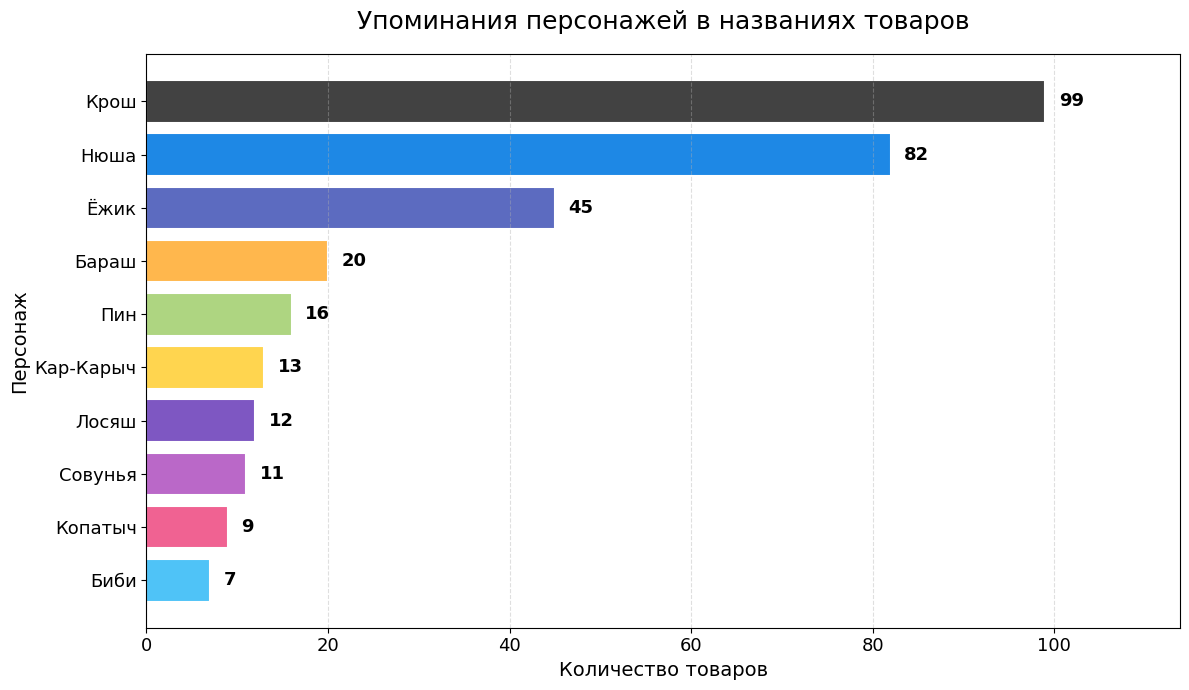

In [ ]:
# Визуализация: какие персонажи чаще встречаются в названиях товаров

if len(character_summary) > 0:
    plot_data = character_summary['products_count'].sort_values()

    colors = [
        smeshariki_palette[i % len(smeshariki_palette)]
        for i in range(len(plot_data))
    ]

    fig, ax = plt.subplots(figsize=(12, 7))

    bars = ax.barh(
        plot_data.index,
        plot_data.values,
        color=colors,
        edgecolor='white',
        linewidth=1.5
    )

    ax.set_title(
        'Упоминания персонажей в названиях товаров',
        fontsize=18,
        pad=18
    )

    ax.set_xlabel(
        'Количество товаров',
        fontsize=14
    )

    ax.set_ylabel(
        'Персонаж',
        fontsize=14
    )

    ax.tick_params(axis='both', labelsize=13)

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )

    max_value = max(plot_data.values)

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + max_value * 0.015,
            bar.get_y() + bar.get_height() / 2,
            int(width),
            va='center',
            fontsize=13,
            fontweight='bold'
        )

    ax.set_xlim(0, max_value * 1.15)

    plt.tight_layout()
    plt.show()

else:
    print('В названиях товаров не найдено явных упоминаний персонажей.')


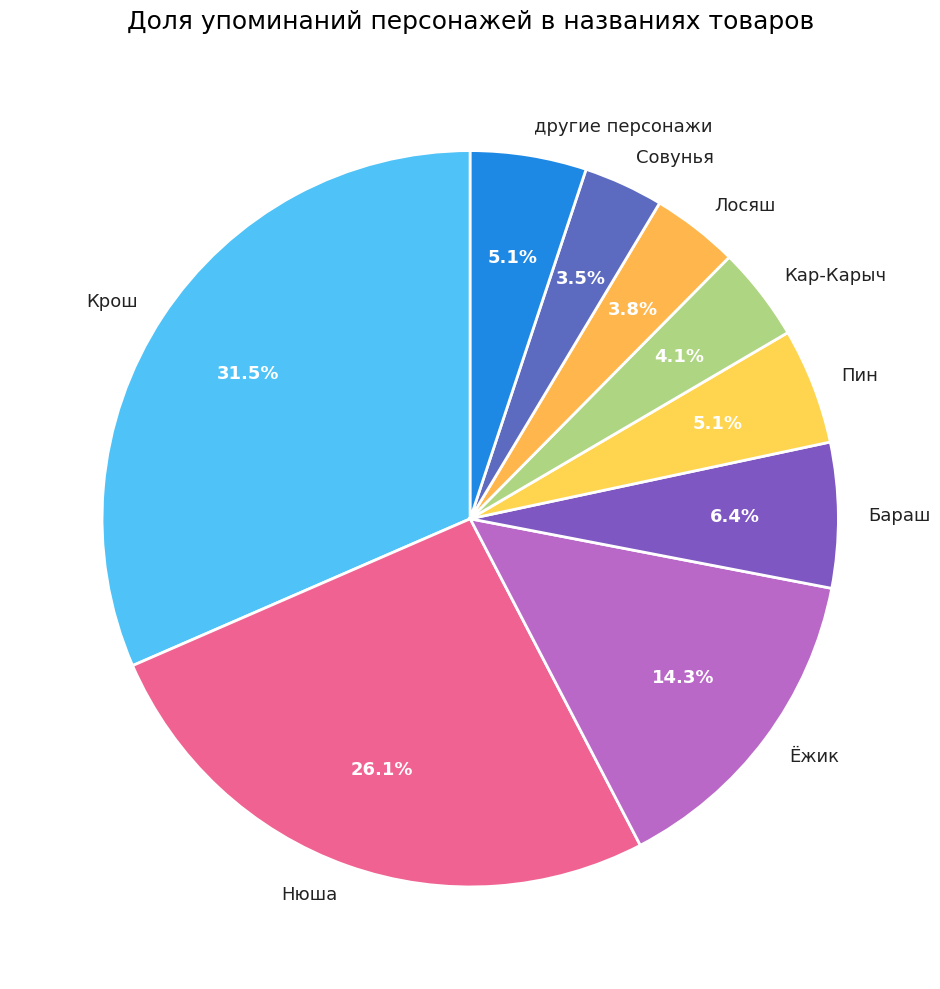

In [ ]:
# Круговая диаграмма: доля упоминаний персонажей в названиях товаров

if len(character_summary) > 0:
    pie_data = character_summary['products_count'].sort_values(ascending=False).copy()

    # Мелкие доли объединяем в "другие персонажи"
    threshold = 3  # проценты
    pie_share = pie_data / pie_data.sum() * 100

    small_characters = pie_share[pie_share < threshold].index

    if len(small_characters) > 0:
        pie_main = pie_data.drop(index=small_characters)
        other_value = pie_data.loc[small_characters].sum()
        pie_plot_data = pd.concat([
            pie_main,
            pd.Series({'другие персонажи': other_value})
        ])
    else:
        pie_plot_data = pie_data.copy()

    colors = [
        smeshariki_palette[i % len(smeshariki_palette)]
        for i in range(len(pie_plot_data))
    ]

    fig, ax = plt.subplots(figsize=(10, 10))

    wedges, texts, autotexts = ax.pie(
        pie_plot_data.values,
        labels=pie_plot_data.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        pctdistance=0.72,
        labeldistance=1.08,
        wedgeprops={
            'edgecolor': 'white',
            'linewidth': 2
        },
        textprops={
            'fontsize': 13
        }
    )

    for text in texts:
        text.set_fontsize(13)
        text.set_color('#222222')

    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    ax.set_title(
        'Доля упоминаний персонажей в названиях товаров',
        fontsize=18,
        pad=22
    )

    plt.tight_layout()
    plt.show()

else:
    print('В названиях товаров не найдено явных упоминаний персонажей.')

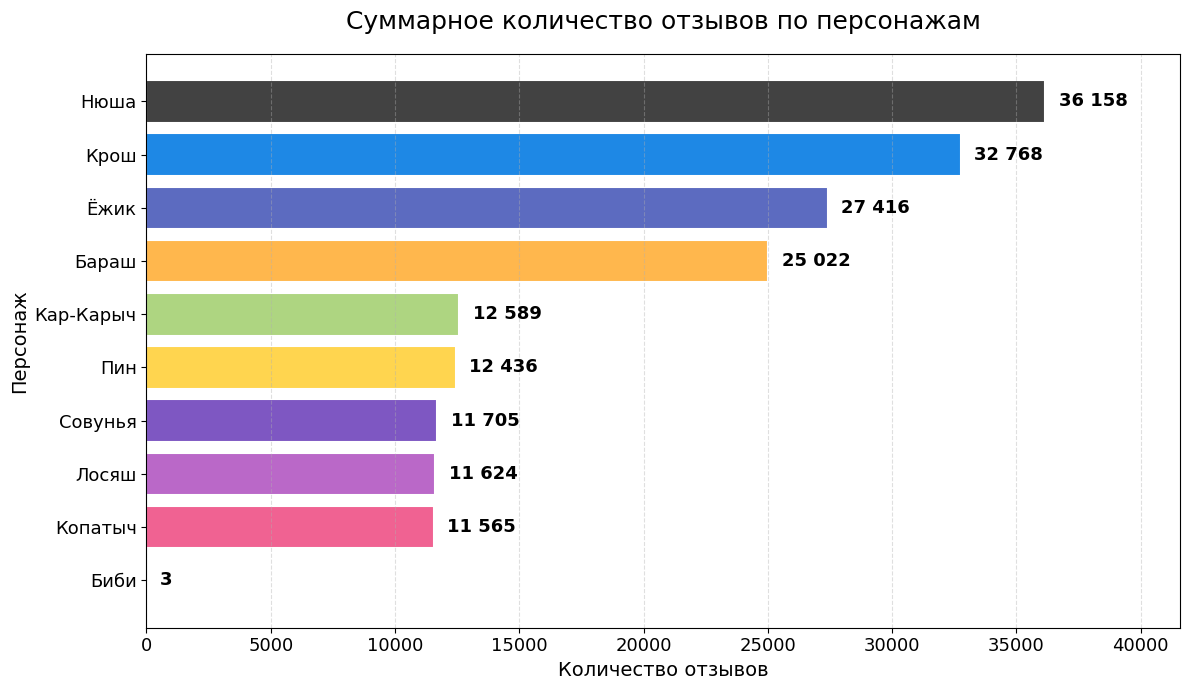

In [ ]:
# Сравним персонажей не только по количеству товаров, но и по отзывам

if len(character_summary) > 0:
    review_plot = character_summary['total_reviews'].sort_values()

    colors = [
        smeshariki_palette[i % len(smeshariki_palette)]
        for i in range(len(review_plot))
    ]

    fig, ax = plt.subplots(figsize=(12, 7))

    bars = ax.barh(
        review_plot.index,
        review_plot.values,
        color=colors,
        edgecolor='white',
        linewidth=1.5
    )

    ax.set_title(
        'Суммарное количество отзывов по персонажам',
        fontsize=18,
        pad=18
    )

    ax.set_xlabel(
        'Количество отзывов',
        fontsize=14
    )

    ax.set_ylabel(
        'Персонаж',
        fontsize=14
    )

    ax.tick_params(axis='both', labelsize=13)

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )

    max_value = max(review_plot.values)

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + max_value * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{int(width):,}'.replace(',', ' '),
            va='center',
            fontsize=13,
            fontweight='bold'
        )

    ax.set_xlim(0, max_value * 1.15)

    plt.tight_layout()
    plt.show()

else:
    print('В названиях товаров не найдено явных упоминаний персонажей.')

### Вывод по блоку 5

В этом блоке персонажи анализировались по двум показателям: по количеству товаров, где имя героя явно упоминается в названии, и по суммарному количеству отзывов у таких товаров. Важно учитывать, что это не абсолютная популярность персонажей в целом: часть товаров может содержать изображение героя, но не указывать его имя в названии карточки.

По количеству товарных карточек лидирует **Крош** — он упоминается в 99 товарах. На втором месте находится **Нюша** — 82 товара, на третьем **Ёжик** — 45 товаров. Вместе эти три персонажа занимают основную часть явных упоминаний: Крош — 31,5%, Нюша — 26,1%, Ёжик — 14,3%. Это показывает, что именно эти герои чаще всего используются в ассортименте как узнаваемые образы бренда.

При этом по суммарному количеству отзывов лидером становится уже **Нюша** — 36 158 отзывов. У Кроша — 32 768 отзывов, у Ёжика — 27 416 отзывов, у Бараша — 25 022 отзыва. То есть Крош чаще встречается в названиях товаров, но товары с Нюшей собирают больше пользовательского отклика.

Это различие важно: количество товаров показывает, насколько активно персонаж используется в ассортименте, а количество отзывов — насколько заметную реакцию собирают товары с этим персонажем. Поэтому нельзя сказать, что самый популярный смешарик один по всем критериям: **по ассортименту лидирует Крош, а по пользовательской активности — Нюша**.

Также видно, что персонажи используются неравномерно. Крош и Нюша сильно выделяются на фоне остальных героев, а Биби почти не представлен: у него всего 7 товаров и 3 отзыва. Это может говорить о том, что в коммерческом ассортименте бренд делает ставку прежде всего на наиболее узнаваемых и массовых персонажей.


## 6. Индекс премиальности категорий

Индекс премиальности показывает, во сколько раз медианная цена категории выше или ниже общей медианной цены по датасету. Если индекс больше 1, категория дороже среднего уровня; если меньше 1 — доступнее среднего.


In [ ]:
overall_median_price = df_clean['discount_price'].median()

premium_index_table = (
    df_clean.groupby('macro_category')
    .agg(
        products_count=('product_id', 'count'),
        median_price=('discount_price', 'median'),
        mean_price=('discount_price', 'mean'),
        total_reviews=('reviews_count', 'sum')
    )
    .assign(
        premium_index=lambda x: x['median_price'] / overall_median_price
    )
    .sort_values('premium_index', ascending=False)
    .round(2)
)

display(premium_index_table)

print(f'Общая медианная цена по датасету: {overall_median_price:.2f} руб.')


,products_count,median_price,mean_price,total_reviews,premium_index
macro_category,,,,,
украшения и ювелирка,68,"6,950.00","8,711.53","68,755.00",13.47
товары для дома и текстиль,26,"1,295.00","1,279.23",582.00,2.51
одежда и обувь,58,"1,203.50","1,781.71","2,483.00",2.33
сумки и рюкзаки,158,"1,003.50","1,016.32","1,988.00",1.94
посуда и товары для еды,2,927.00,927.00,0.00,1.80
игрушки и игры,579,875.00,"1,307.22","36,770.00",1.70
не определено,15,638.00,"2,392.93","21,005.00",1.24
книги и медиа,328,551.50,614.87,"67,025.00",1.07
подарочная упаковка,100,495.50,596.90,"3,046.00",0.96


Общая медианная цена по датасету: 516.00 руб.


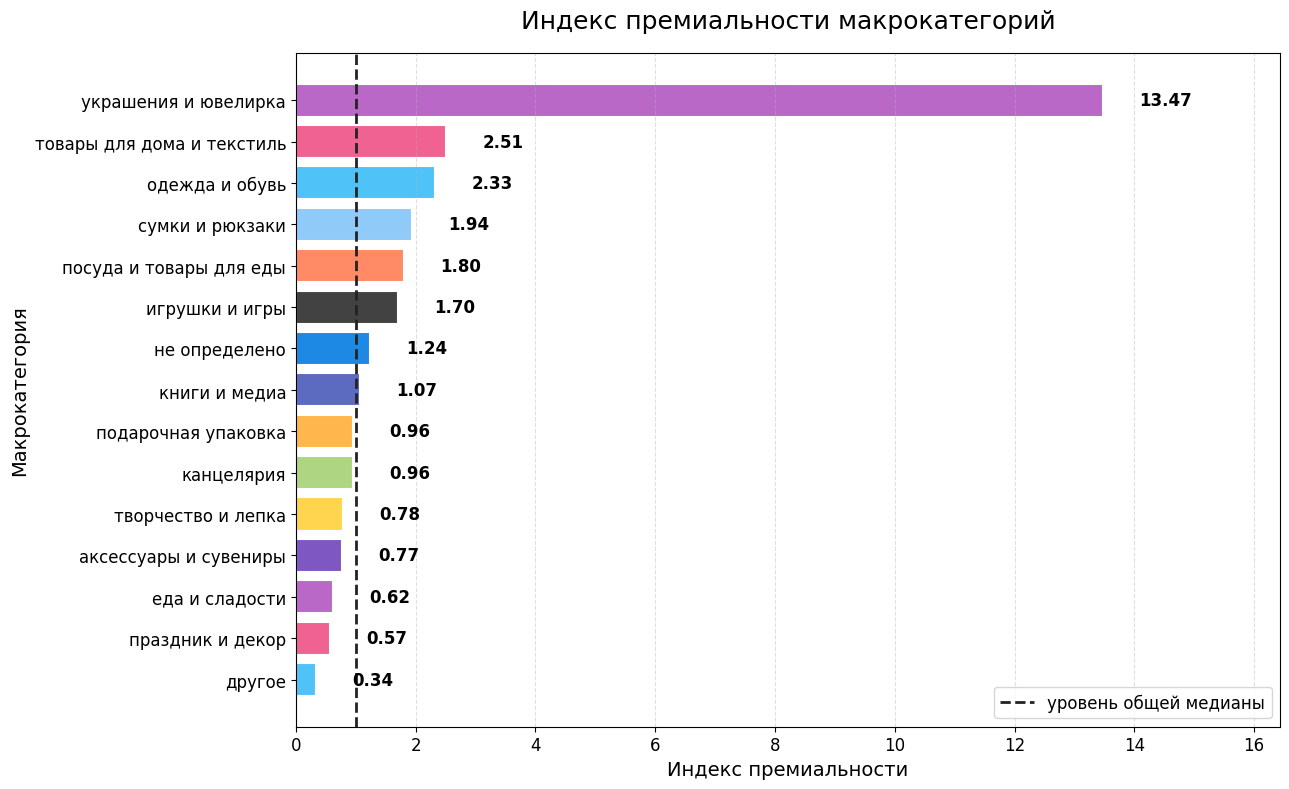

In [ ]:
# Индекс премиальности макрокатегорий

premium_plot = premium_index_table['premium_index'].sort_values()

colors = [
    smeshariki_palette[i % len(smeshariki_palette)]
    for i in range(len(premium_plot))
]

fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(
    premium_plot.index,
    premium_plot.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

# Линия общей медианы
ax.axvline(
    1,
    color='#222222',
    linestyle='--',
    linewidth=2,
    label='уровень общей медианы'
)

ax.set_title(
    'Индекс премиальности макрокатегорий',
    fontsize=18,
    pad=18
)

ax.set_xlabel(
    'Индекс премиальности',
    fontsize=14
)

ax.set_ylabel(
    'Макрокатегория',
    fontsize=14
)

ax.tick_params(axis='both', labelsize=12)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

max_value = max(premium_plot.values)

# Подписи значений справа от столбцов
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + max_value * 0.045,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va='center',
        ha='left',
        fontsize=12,
        fontweight='bold'
    )

# Увеличиваем правую границу, чтобы подписи влезали
ax.set_xlim(0, max_value * 1.22)

ax.legend(
    fontsize=12,
    loc='lower right',
    frameon=True
)

plt.tight_layout()
plt.show()

In [ ]:
# Посмотреть товары из категории "другое"

other_goods = df_clean[
    df_clean['macro_category'] == 'другое'
].copy()

print('Количество товаров в категории "другое":', len(other_goods))

display(
    other_goods[
        [
            'product_name',
            'category_name',
            'marketplace',
            'brand',
            'seller',
            'price',
            'discount_price',
            'reviews_count',
            'link'
        ]
    ]
    .sort_values('price', ascending=False)
    .head(50)
)

Количество товаров в категории "другое": 3


,product_name,category_name,marketplace,brand,seller,price,discount_price,reviews_count,link
2224,Зонт-трость со Смешариками,<NA>,Wildberries,PlayToday,АО ПЛЭЙТУДЭЙ СНГ,1747,688,24.00,https://www.wildberries.ru/catalog/254269667/d...
28,Благодарность -грамота,грамоты и дипломы,Wildberries,Смешарики,MaxSeller,711,176,1.00,https://www.wildberries.ru/catalog/97196123/de...
58,"Набор на выпускной ""Выпускник детского сада""",<NA>,Wildberries,Смешарики,ПРЯМОЙ КОНТРАКТ - Официальный магазин,517,100,277.00,https://www.wildberries.ru/catalog/225333876/d...


### Вывод по индексу премиальности

Индекс премиальности показывает, во сколько раз медианная цена товаров в макрокатегории отличается от общей медианной цены по датасету. В нашем случае общая медианная цена составляет **516 руб.** Значение индекса выше 1 означает, что категория дороже общей медианы, а значение ниже 1 — что категория относится к более доступному сегменту.

Самой премиальной категорией оказались **украшения и ювелирка**: медианная цена в этой группе составляет **6950 руб.**, а индекс премиальности равен **13,47**. Это резко выделяет категорию на фоне остальных товаров. Такой результат объясняется тем, что сюда входят запонки, подвески, браслеты и серьги из коллекции SASONKO. Эти товары сложно рассматривать как обычный детский мерч: скорее это подарочные, коллекционные или взрослые ностальгические покупки.

Также индекс выше 1 имеют **товары для дома и текстиль** — 2,51, **одежда и обувь** — 2,33, **сумки и рюкзаки** — 1,94, **посуда и товары для еды** — 1,80, **игрушки и игры** — 1,70, **книги и медиа** — 1,07. Эти категории дороже общей медианы, но отличаются по смыслу. Например, одежда и обувь могут быть связаны с фанатской или ностальгической покупкой, особенно если речь идёт о кедах. Сумки, текстиль и посуда ближе к повседневному мерчу, где бренд используется уже не только для детской игры, но и как узнаваемый образ в обычных вещах.

К более доступным категориям относятся **праздник и декор**, **еда и сладости**, **аксессуары и сувениры**, **творчество и лепка**, **канцелярия** и **подарочная упаковка**. Их индекс ниже 1, то есть медианная цена меньше общей медианы по датасету. Эти категории можно считать массовыми: они дешевле, чаще покупаются как небольшие повседневные товары и лучше подходят для детского или семейного сценария покупки.

Таким образом, индекс премиальности показывает, что ассортимент «Смешариков» делится на два уровня. Первый — массовый и доступный: сладости, канцелярия, творчество, декор и небольшие сувениры. Второй — более дорогой и нишевый: украшения, одежда, обувь, сумки, текстиль и часть игрушек. Это хорошо связано с идеей экономики ностальгии: бренд работает не только как детский визуальный образ, но и как эмоциональный символ, за который взрослая аудитория может быть готова платить больше.

## 7. Портрет типичного покупателя

На основе собранных данных нельзя точно определить возраст, пол или социальный статус покупателя. Поэтому здесь формируется не демографический портрет, а **портрет возможных сценариев покупки**: какие люди и зачем могут покупать современную продукцию «Смешариков».


In [ ]:
# Автоматическая заготовка для вывода о типичном покупателе

top_category = (
    assortment_distribution
    .sort_values('products_count', ascending=False)
    .index[0]
)

# price_segment_table могла быть создана либо с английскими, либо с русскими названиями
price_count_col = (
    'products_count'
    if 'products_count' in price_segment_table.columns
    else 'Количество товаров'
)

top_price_segment = (
    price_segment_table
    .sort_values(price_count_col, ascending=False)
    .index[0]
)

top_activity_category = (
    activity_by_category
    .sort_values('total_reviews', ascending=False)
    .index[0]
)

if len(character_summary) > 0:
    top_character_by_products = (
        character_summary
        .sort_values('products_count', ascending=False)
        .index[0]
    )

    top_character_by_reviews = (
        character_summary
        .sort_values('total_reviews', ascending=False)
        .index[0]
    )
else:
    top_character_by_products = 'не определён'
    top_character_by_reviews = 'не определён'

print('Основная категория ассортимента:', top_category)
print('Самый частый ценовой сегмент:', top_price_segment)
print('Категория с наибольшим числом отзывов:', top_activity_category)
print('Самый часто упоминаемый персонаж:', top_character_by_products)
print('Персонаж с наибольшим числом отзывов:', top_character_by_reviews)
print('Медианная цена товара:', round(overall_median_price, 2), 'руб.')

Основная категория ассортимента: игрушки и игры
Самый частый ценовой сегмент: до 500 ₽
Категория с наибольшим числом отзывов: украшения и ювелирка
Самый часто упоминаемый персонаж: Крош
Персонаж с наибольшим числом отзывов: Нюша
Медианная цена товара: 516.0 руб.


In [ ]:
# Покупательские сценарии на основе макрокатегорий

scenario_map = {
    # Массовая семейная / детская покупка
    'игрушки и игры': 'массовая семейная покупка',
    'канцелярия': 'массовая семейная покупка',
    'творчество и лепка': 'массовая семейная покупка',
    'еда и сладости': 'массовая семейная покупка',
    'книги и медиа': 'массовая семейная покупка',
    'праздник и декор': 'массовая семейная покупка',
    'подарочная упаковка': 'массовая семейная покупка',

    # Повседневный мерч
    'сумки и рюкзаки': 'повседневный мерч',
    'посуда и товары для еды': 'повседневный мерч',
    'товары для дома и текстиль': 'повседневный мерч',
    'аксессуары и сувениры': 'повседневный мерч',

    # Ностальгическая / фанатская покупка
    'одежда и обувь': 'ностальгическая / фанатская покупка',

    # Премиальный / подарочный сегмент
    'украшения и ювелирка': 'премиальный / подарочный сегмент'
}

df_clean['buyer_scenario'] = (
    df_clean['macro_category']
    .map(scenario_map)
    .fillna('прочее / не определено')
)

buyer_scenario_table = (
    df_clean.groupby('buyer_scenario')
    .agg(
        products_count=('buyer_scenario', 'size'),
        unique_categories=('macro_category', 'nunique'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean'),
        min_price=('price', 'min'),
        max_price=('price', 'max'),
        total_reviews=('reviews_count', 'sum'),
        products_with_reviews=('has_reviews', 'sum'),
        mean_rating=('rating_active', 'mean')
    )
)

buyer_scenario_table['share_percent'] = (
    buyer_scenario_table['products_count']
    / buyer_scenario_table['products_count'].sum()
    * 100
).round(2)

buyer_scenario_table['share_with_reviews_percent'] = (
    buyer_scenario_table['products_with_reviews']
    / buyer_scenario_table['products_count']
    * 100
).round(2)

buyer_scenario_table = (
    buyer_scenario_table
    .sort_values('products_count', ascending=False)
    .round(2)
)

buyer_scenario_table

,products_count,unique_categories,median_price,mean_price,min_price,max_price,total_reviews,products_with_reviews,mean_rating,share_percent,share_with_reviews_percent
buyer_scenario,,,,,,,,,,,
массовая семейная покупка,2616,7,"1,299.00","1,776.47",115,40000,"180,163.00",497,4.83,88.32,19.00
повседневный мерч,202,4,"2,123.00","2,710.69",423,9800,"3,446.00",67,4.93,6.82,33.17
премиальный / подарочный сегмент,68,1,"6,950.00","9,076.16",341,90000,"68,755.00",20,4.86,2.30,29.41
ностальгическая / фанатская покупка,58,1,"3,349.00","3,639.12",418,8999,"2,483.00",50,4.91,1.96,86.21
прочее / не определено,18,2,814.00,"7,405.39",231,101364,"21,307.00",12,4.86,0.61,66.67


In [ ]:
# Красивая таблица покупательских сценариев

buyer_scenario_table_ru = (
    buyer_scenario_table
    .reset_index()
    .rename(columns={
        'buyer_scenario': 'Покупательский сценарий',
        'products_count': 'Количество товаров',
        'unique_categories': 'Число макрокатегорий',
        'median_price': 'Медианная цена, ₽',
        'mean_price': 'Средняя цена, ₽',
        'min_price': 'Минимальная цена, ₽',
        'max_price': 'Максимальная цена, ₽',
        'total_reviews': 'Всего отзывов',
        'products_with_reviews': 'Товаров с отзывами',
        'mean_rating': 'Средний рейтинг',
        'share_percent': 'Доля ассортимента, %',
        'share_with_reviews_percent': 'Доля товаров с отзывами, %'
    })
)

buyer_scenario_table_ru.index = buyer_scenario_table_ru.index + 1

def fmt_int(x):
    if pd.isna(x):
        return ''
    return f'{x:,.0f}'.replace(',', ' ')

def fmt_price(x):
    if pd.isna(x):
        return ''
    return f'{x:,.0f}'.replace(',', ' ')

def fmt_percent(x):
    if pd.isna(x):
        return ''
    return f'{x:.2f}'.replace('.', ',')

def fmt_rating(x):
    if pd.isna(x):
        return ''
    return f'{x:.2f}'.replace('.', ',')

styled_buyer_scenario_table = (
    buyer_scenario_table_ru.style
    .format({
        'Количество товаров': fmt_int,
        'Число макрокатегорий': fmt_int,
        'Медианная цена, ₽': fmt_price,
        'Средняя цена, ₽': fmt_price,
        'Минимальная цена, ₽': fmt_price,
        'Максимальная цена, ₽': fmt_price,
        'Всего отзывов': fmt_int,
        'Товаров с отзывами': fmt_int,
        'Средний рейтинг': fmt_rating,
        'Доля ассортимента, %': fmt_percent,
        'Доля товаров с отзывами, %': fmt_percent
    })
    .set_caption('Покупательские сценарии по ассортименту, ценам и отзывам')
    .background_gradient(subset=['Доля ассортимента, %'], cmap='Purples')
    .background_gradient(subset=['Медианная цена, ₽'], cmap='Oranges')
    .background_gradient(subset=['Всего отзывов'], cmap='Greens')
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '12px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#FCE4EC'),
                ('color', '#222222'),
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('border', '1px solid #dddddd'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('padding', '8px'),
                ('font-size', '11px'),
                ('text-align', 'center')
            ]
        }
    ])
    .set_properties(subset=['Покупательский сценарий'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
)

display(styled_buyer_scenario_table)

,Покупательский сценарий,Количество товаров,Число макрокатегорий,"Медианная цена, ₽","Средняя цена, ₽","Минимальная цена, ₽","Максимальная цена, ₽",Всего отзывов,Товаров с отзывами,Средний рейтинг,"Доля ассортимента, %","Доля товаров с отзывами, %"
1,массовая семейная покупка,2 616,7,1 299,1 776,115,40 000,180 163,497,"4,83","88,32","19,00"
2,повседневный мерч,202,4,2 123,2 711,423,9 800,3 446,67,"4,93","6,82","33,17"
3,премиальный / подарочный сегмент,68,1,6 950,9 076,341,90 000,68 755,20,"4,86","2,30","29,41"
4,ностальгическая / фанатская покупка,58,1,3 349,3 639,418,8 999,2 483,50,"4,91","1,96","86,21"
5,прочее / не определено,18,2,814,7 405,231,101 364,21 307,12,"4,86","0,61","66,67"


### Вывод по покупательским сценариям

По данным видно, что говорить об одном «типичном покупателе» некорректно: ассортимент «Смешариков» распадается на несколько разных покупательских сценариев. Они отличаются по доле в ассортименте, уровню цен и пользовательской активности.

Основной сценарий — **массовая семейная покупка**. В него входят 2616 товаров, то есть **88,32% ассортимента**. Сюда относятся игрушки, канцелярия, творчество, сладости, книги, праздничные товары и подарочная упаковка. Медианная цена в этом сценарии составляет **1299 руб.**, а всего товары собрали **180 163 отзыва**. Это самый широкий слой ассортимента, который можно связать с детскими и семейными покупками: товары покупаются для детей, школы, творчества, праздников или как недорогой знакомый мерч.

Второй сценарий — **повседневный мерч**. Он занимает только **6,82% ассортимента**, но его медианная цена выше — **2123 руб.** Сюда попадают сумки, рюкзаки, товары для дома, текстиль, посуда и аксессуары. Эти товары уже не обязательно выглядят как чисто детская покупка: бренд используется как узнаваемый визуальный образ, который можно встроить в повседневную жизнь.

Отдельно выделяется **ностальгическая / фанатская покупка**. Этот сценарий включает всего **58 товаров**, то есть **1,96% ассортимента**, но медианная цена здесь составляет **3349 руб.**, а доля товаров с отзывами — **86,21%**. Это самый высокий показатель среди всех сценариев. Такой результат показывает, что товары этого сегмента, например одежда и обувь, менее массовые, но заметно более «живые» по пользовательской реакции. Их можно интерпретировать как покупки для тех, кто выбирает товар не только из-за функции, но и из-за эмоциональной связи с брендом.

**Премиальный / подарочный сегмент** занимает **2,30% ассортимента**, но имеет самую высокую медианную цену — **6950 руб.**, а максимальная цена достигает **90 000 руб.** Сюда попадают украшения и ювелирка. Такой сегмент явно отличается от массового мерча: это скорее подарочные, коллекционные или взрослые ностальгические покупки, где ценность создаётся не только самим товаром, но и связью с узнаваемым брендом.

Таким образом, данные подтверждают, что продукция «Смешарики» работает сразу в нескольких слоях: как массовый детский и семейный товар, как повседневный мерч, как фанатская покупка и как премиальный подарок. Это хорошо отражает идею экономики ностальгии: знакомый с детства бренд может продаваться не только через дешёвые товары, но и через более дорогие эмоциональные и статусные покупки.

## 8. Итоговые таблицы для отчёта

Сохраняем очищенный датасет и основные таблицы, которые могут понадобиться для отчёта или презентации.


In [ ]:
# Сохраняем очищенный датасет
clean_csv_path = 'smeshariki_clean_course.csv'
df_clean.to_csv(clean_csv_path, index=False, encoding='utf-8-sig')
print('Очищенный датасет сохранён:', clean_csv_path)

# Сохраняем таблицы для отчёта
report_xlsx_path = 'smeshariki_report_tables.xlsx'

with pd.ExcelWriter(report_xlsx_path, engine='openpyxl') as writer:
    missing_table.to_excel(writer, sheet_name='missing')
    assortment_distribution.to_excel(writer, sheet_name='assortment_distribution')
    assortment_table.to_excel(writer, sheet_name='assortment_table')
    price_by_category.to_excel(writer, sheet_name='price_by_category')
    price_segment_table.to_excel(writer, sheet_name='price_segments')
    price_segment_by_category.to_excel(writer, sheet_name='segments_by_category')
    activity_by_category.to_excel(writer, sheet_name='activity_by_category')
    corr_spearman.to_excel(writer, sheet_name='corr_spearman')
    corr_pearson.to_excel(writer, sheet_name='corr_pearson')
    character_summary.to_excel(writer, sheet_name='characters')
    premium_index_table.to_excel(writer, sheet_name='premium_index')

print('Таблицы для отчёта сохранены:', report_xlsx_path)


Очищенный датасет сохранён: smeshariki_clean_course.csv
Таблицы для отчёта сохранены: smeshariki_report_tables.xlsx


## 9. Итоговые выводы по исследованию

### 1. Подготовка и очистка данных

В ходе работы данные были объединены из нескольких источников и приведены к единой структуре. В датасете оказались товары с маркетплейсов, официальных и тематических магазинов, поэтому сначала было важно унифицировать названия столбцов, числовые признаки, категории и источники.

Были проверены пропуски, дубликаты, цены, рейтинги и количество отзывов. Отдельно были восстановлены категории товаров и созданы укрупнённые макрокатегории: игрушки и игры, канцелярия, творчество и лепка, еда и сладости, книги и медиа, одежда и обувь, украшения и ювелирка и другие.

Ценовые выбросы не удалялись автоматически, потому что в данном исследовании они являются не только технической проблемой, но и частью смысла данных. Очень дорогие товары, например ювелирка или лимитированный мерч, показывают существование премиального и нишевого сегмента продукции «Смешарики».

### 2. Ассортимент продукции

Ассортимент в основном сосредоточен в массовых категориях. Наиболее широко представлены **игрушки и игры**, **канцелярия**, **творчество и лепка**, **еда и сладости**, **книги и медиа**. Вместе эти категории формируют основную часть датасета и показывают, что бренд по-прежнему активно работает в детском и семейном сегменте.

При этом ассортимент не ограничивается только игрушками. В данных есть товары для школы, творчества, праздников, дома, одежда, обувь, сумки, рюкзаки, аксессуары и украшения. Это важно для темы исследования: «Смешарики» существуют не только как детский мультфильм, но и как коммерческий бренд, который используется в разных товарных форматах.

По брендам ожидаемо выделяется сам бренд **«Смешарики»**, так как значительная часть товаров маркируется именно им. Если смотреть на продавцов и производителей без учёта самого бренда, становятся видны отдельные участники ассортимента, которые специализируются на конкретных категориях товаров.

### 3. Ценовая аналитика

Распределение цен сильно скошено вправо: основная масса товаров находится в доступных ценовых сегментах, но при этом в датасете есть отдельные очень дорогие позиции. Поэтому для интерпретации цен важнее использовать медиану, а не среднее значение: средняя цена заметно искажается из-за дорогих товаров.

Больше всего товаров находится в сегментах **до 500 руб.** и **500–1500 руб.**. Это подтверждает, что основа ассортимента — массовые и относительно доступные товары: канцелярия, сладости, товары для творчества, праздничный декор и часть игрушек.

Но одновременно выделяется группа дорогих категорий. Самая заметная из них — **украшения и ювелирка**, где медианная цена составляет **6950 руб.** Также выше общей медианы находятся **одежда и обувь**, **товары для дома и текстиль**, **сумки и рюкзаки**, часть игрушек и книг. Эти категории уже сложнее воспринимать как обычные детские покупки: они ближе к подарочному, фанатскому или ностальгическому потреблению.

### 4. Пользовательская активность

Отзывы есть не у всех товаров: значительная часть ассортимента представлена в продаже, но не имеет пользовательской реакции в виде отзывов. Поэтому количество отзывов в работе рассматривается как косвенный показатель активности покупателей, а не как точная оценка продаж.

Больше всего отзывов собирают массовые категории, потому что именно они представлены шире и чаще попадают в повседневные покупки. При этом рейтинг анализировался только среди товаров с отзывами, потому что отсутствие рейтинга у товара без отзывов не означает плохую оценку.

Связь между ценой и количеством отзывов оказалась слабой. Это логично: популярность товара объясняется не только ценой, но и категорией, персонажем, площадкой, типом товара, визуальной привлекательностью и самим сценарием покупки. Недорогой товар может быть массовым, но дорогой товар может быть важен как подарок или фанатский объект.

### 5. Самый популярный смешарик

Анализ персонажей проводился по названиям товаров, поэтому он показывает не абсолютную популярность героев, а частоту их явного упоминания в товарных карточках.

По количеству упоминаний лидирует **Крош**: он чаще всего встречается в названиях товаров. Далее идут **Нюша** и **Ёжик**. Это показывает, что именно эти персонажи чаще всего используются как узнаваемые образы в ассортименте.

Однако по суммарному количеству отзывов лидирует уже **Нюша**. Это важное различие: Крош чаще используется в товарных карточках, но товары с Нюшей собирают больший пользовательский отклик. Поэтому нельзя назвать одного абсолютного лидера по всем критериям: **по ассортименту лидирует Крош, а по отзывам — Нюша**.

Также видно, что часть товаров продаётся не через конкретного героя, а через общий бренд «Смешарики». Это значит, что коммерческая сила бренда держится не только на отдельных персонажах, но и на узнаваемости всей франшизы.

### 6. Индекс премиальности

Индекс премиальности показывает, во сколько раз медианная цена категории отличается от общей медианной цены по датасету. Общая медианная цена составляет **516 руб.**

Категории с индексом выше 1 можно считать более дорогими относительно общего уровня. Сильнее всего выделяется **украшения и ювелирка**: индекс премиальности равен **13,47**, а медианная цена — **6950 руб.** Это резко отделяет эту категорию от массового ассортимента. Такие товары скорее относятся к подарочным, коллекционным или взрослым ностальгическим покупкам.

Также выше общей медианы находятся **товары для дома и текстиль**, **одежда и обувь**, **сумки и рюкзаки**, **посуда и товары для еды**, **игрушки и игры**, **книги и медиа**. Эти категории показывают, что бренд может использоваться не только в дешёвых детских товарах, но и в более дорогих предметах повседневного мерча, одежды, подарков и коллекционных вещей.

Категории с индексом ниже 1 — **еда и сладости**, **праздник и декор**, **творчество и лепка**, **канцелярия**, **подарочная упаковка**, **аксессуары и сувениры** — относятся к более массовому и доступному ассортименту. Они лучше всего соответствуют детскому и семейному сценарию покупки.

### 7. Покупательские сценарии

По данным нельзя точно определить возраст, пол или реальные мотивы покупателей, потому что в датасете нет демографической информации. Но по структуре ассортимента, ценам и отзывам можно выделить несколько вероятных покупательских сценариев.

Главный сценарий — **массовая семейная покупка**. Он включает **2616 товаров**, то есть **88,32% ассортимента**. Это игрушки, канцелярия, творчество, сладости, книги, праздничные товары и подарочная упаковка. Такой сегмент, скорее всего, связан с покупками для детей, школы, праздников и повседневного использования.

Второй сценарий — **повседневный мерч**. Он занимает **6,82% ассортимента**, но имеет более высокую медианную цену — **2123 руб.** Сюда относятся сумки, рюкзаки, товары для дома, текстиль, посуда и аксессуары. Эти товары уже могут быть интересны не только детям, но и подросткам или взрослым, которым нравится визуальный образ бренда.

Отдельно выделяется **ностальгическая / фанатская покупка**. Она занимает всего **1,96% ассортимента**, но медианная цена здесь выше — **3349 руб.**, а доля товаров с отзывами составляет **86,21%**. Это указывает на небольшую, но более вовлечённую группу товаров. Сюда относятся одежда и обувь, например кеды, которые сложно объяснить только как детскую покупку. Скорее это товары для людей, которые воспринимают «Смешариков» как часть личной памяти, стиля или фанатской идентичности.

Ещё один важный сценарий — **премиальный / подарочный сегмент**. Он занимает **2,30% ассортимента**, но имеет самую высокую медианную цену — **6950 руб.**, а максимальная цена достигает **90 000 руб.** Сюда относятся украшения и ювелирка. Это уже явно взрослый сегмент: такие товары могут покупаться как подарок, коллекционный объект или ностальгическая вещь с высоким эмоциональным значением.

Таким образом, несмотря на явное преобладание детско-семейного сегмента, в данных хорошо видна отдельная группа товаров для взрослых покупателей. Она меньше по объёму, но заметно дороже и лучше связана с идеей ностальгии.

### Общий вывод

В итоге видно, что «Смешарики» сейчас существуют не просто как детский мультфильм, по которому делают игрушки. Да, основа ассортимента всё ещё довольно ожидаемая: игрушки, канцелярия, творчество, сладости, книги и праздничные товары. То есть большая часть продукции действительно укладывается в детско-семейный сегмент: это то, что могут покупать детям, для школы, для праздников или просто как недорогой мерч со знакомыми персонажами.

Но этим всё не ограничивается. Когда мы смотрим не только на количество товаров, но и на цены, категории и индекс премиальности, появляется другая часть ассортимента: кеды, одежда, сумки, товары для дома, украшения и ювелирка. Эти товары уже сложнее объяснить как обычную детскую покупку. Особенно ювелирка и обувь: они дороже, их меньше, но именно поэтому они хорошо показывают, что бренд работает ещё и на взрослую аудиторию.

Получается, что у «Смешариков» есть два слоя. Первый — массовый и детский, где бренд используется как понятный, яркий и узнаваемый образ. Второй — более взрослый и ностальгический, где человек покупает не просто вещь с персонажем, а какую-то связь с детством, воспоминанием, вайбом или личной симпатией к этому миру.

Поэтому главная идея исследования в том, что «Смешарики» — это уже не только детский бренд. Несмотря на то что количественно преобладает детско-семейный ассортимент, по дорогим и нишевым категориям видно отдельный взрослый сегмент. Именно там и проявляется экономика ностальгии: знакомый образ из детства превращается в товары, за которые взрослый покупатель готов платить не только из-за функции, но и из-за эмоции.
